In [1]:
import json
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

plt.rcParams.update({'figure.dpi': 130, 'font.size': 11})
LOGS = Path('logs/siren')

## 1 · Load results

In [2]:
records = []
for p in sorted(LOGS.glob('s*/report.json')):
    r   = json.loads(p.read_text())
    cfg = r['config']
    m   = json.loads((p.parent / 'metrics.json').read_text()) if (p.parent / 'metrics.json').exists() else {}
    records.append({
        'run':            p.parent.name,
        'layers':         cfg['hidden_layers'],
        'neurons':        cfg['hidden_features'],
        'omega_0':        cfg['omega_0'],
        'batch_size':     cfg['batch_size'],
        'n_params':       r['n_params'],
        'best_psnr':      r['best_psnr'],
        'best_loss':      r['best_loss'],
        'epochs_trained': r['epochs_trained'],
        'train_sec':      r['train_sec'],
        'ssim':           m.get('ssim'),
        'lpips':          m.get('lpips'),
    })

df = pd.DataFrame(records).sort_values('run').reset_index(drop=True)
df['train_min']  = (df['train_sec'] / 60).round(1)
df['n_params_k'] = (df['n_params'] / 1e3).round(1)

display(df[['run','layers','neurons','omega_0','n_params_k','best_psnr',
            'ssim','lpips','epochs_trained','train_min']]
        .rename(columns={'n_params_k':'params_k','best_psnr':'PSNR (dB)',
                         'epochs_trained':'epochs','train_min':'time (min)'})
        .to_string(index=False))


'      run  layers  neurons  omega_0  params_k  PSNR (dB)     ssim    lpips  epochs  time (min)\ns3128_w30       3      128     30.0      50.2  40.026021 0.928798 0.060771     891         6.3\ns3256_w10       3      256     10.0     198.7  39.945964 0.928614 0.067788     616       123.9\ns3256_w30       3      256     30.0     198.7  40.689074 0.930670 0.047685     345         5.8\ns3256_w60       3      256     60.0     198.7  40.454497 0.930278 0.040849     100        20.1\ns3512_w30       3      512     30.0     790.5  40.968833 0.931974 0.042472     369       168.1\ns4256_w30       4      256     30.0     264.4  40.966537 0.931791 0.041785     417       125.3'

## 2 · Load loss curves

In [3]:
def load_loss_curve(run_dir: Path):
    """Load loss txt, convert MSE → PSNR, return running-maximum (best-so-far) curve."""
    txts = sorted(run_dir.glob('checkpoints/*losses_final.txt'))
    if not txts:
        return None
    losses = np.loadtxt(txts[-1])
    psnr   = -10 * np.log10(losses + 1e-8)
    return np.maximum.accumulate(psnr)   # running best — removes step-level noise

curves = {}
for p in sorted(LOGS.glob('s*/report.json')):
    name = p.parent.name
    c    = load_loss_curve(p.parent)
    if c is not None:
        curves[name] = c
        print(f'{name}: {len(c):,} steps  final PSNR {c[-1]:.2f} dB')


s3128_w30: 100,344 steps  final PSNR 40.09 dB
s3256_w10: 69,608 steps  final PSNR 40.01 dB
s3256_w30: 37,504 steps  final PSNR 40.74 dB
s3256_w60: 11,300 steps  final PSNR 40.55 dB
s3512_w30: 41,697 steps  final PSNR 41.03 dB
s4256_w30: 47,121 steps  final PSNR 41.02 dB


## 3 · Depth ablation  (layers=3,4 · neurons=256 · ω=30)

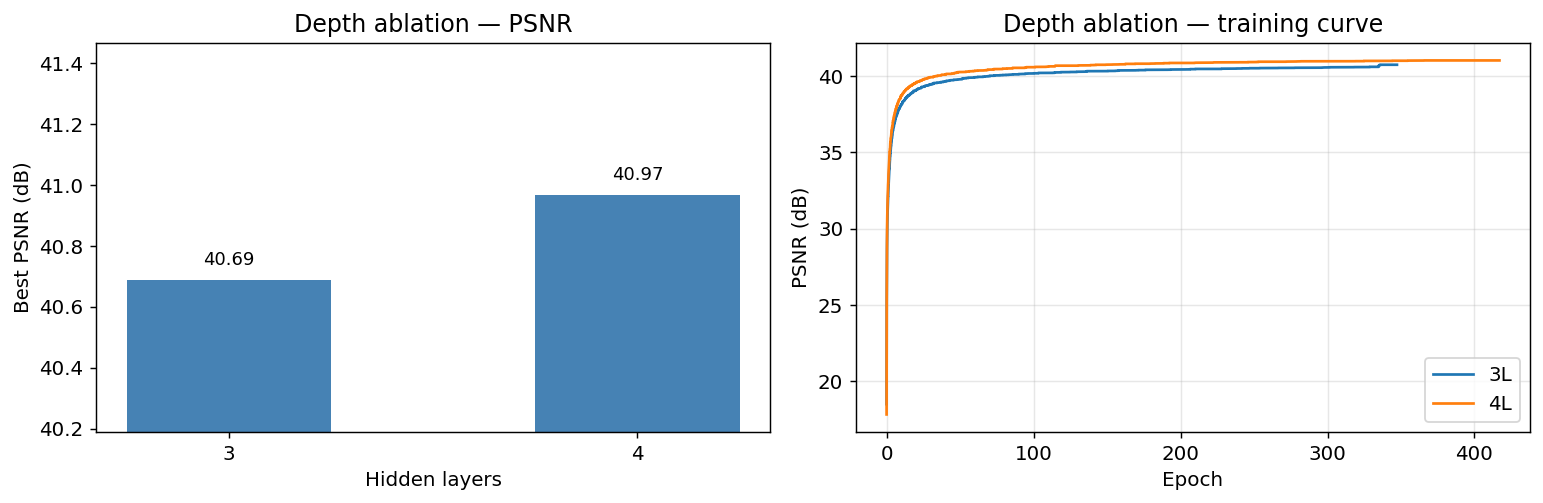

In [4]:
depth = df[(df.neurons == 256) & (df.omega_0 == 30)].sort_values('layers')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.bar(depth['layers'].astype(str), depth['best_psnr'], color='steelblue', width=0.5)
ax.set_xlabel('Hidden layers')
ax.set_ylabel('Best PSNR (dB)')
ax.set_title('Depth ablation — PSNR')
ax.set_ylim(depth['best_psnr'].min() - 0.5, depth['best_psnr'].max() + 0.5)
for bar, v in zip(ax.patches, depth['best_psnr']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, f'{v:.2f}', ha='center', fontsize=10)

ax = axes[1]
for _, row in depth.iterrows():
    name = row['run']
    if name in curves:
        c = curves[name]
        steps_per_ep = len(c) // row['epochs_trained']
        epochs = np.arange(len(c)) / max(steps_per_ep, 1)
        ax.plot(epochs, c, label=f"{row['layers']}L")
ax.set_xlabel('Epoch')
ax.set_ylabel('PSNR (dB)')
ax.set_title('Depth ablation — training curve')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(LOGS / 'ablation' / 'depth_ablation.pdf', dpi=600, bbox_inches='tight')
plt.show()

## 4 · Width ablation  (layers=3 · neurons=128,256,512 · ω=30)

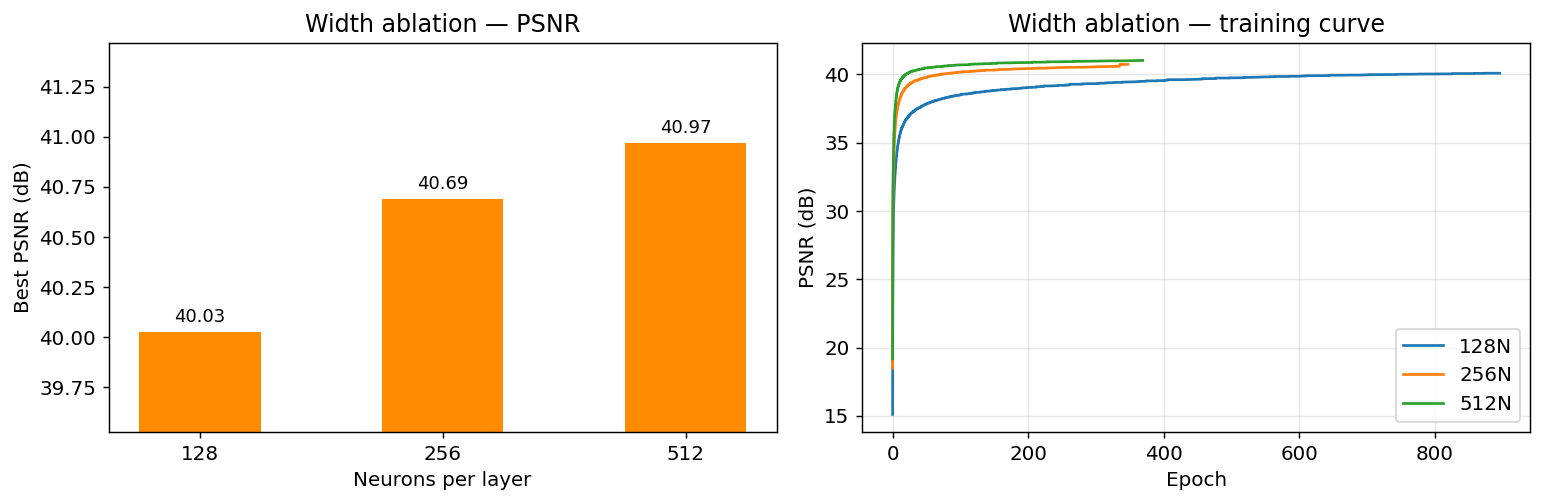

In [5]:
width = df[(df.layers == 3) & (df.omega_0 == 30)].sort_values('neurons')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.bar(width['neurons'].astype(str), width['best_psnr'], color='darkorange', width=0.5)
ax.set_xlabel('Neurons per layer')
ax.set_ylabel('Best PSNR (dB)')
ax.set_title('Width ablation — PSNR')
ax.set_ylim(width['best_psnr'].min() - 0.5, width['best_psnr'].max() + 0.5)
for bar, v in zip(ax.patches, width['best_psnr']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, f'{v:.2f}', ha='center', fontsize=10)

ax = axes[1]
for _, row in width.iterrows():
    name = row['run']
    if name in curves:
        c = curves[name]
        steps_per_ep = len(c) // row['epochs_trained']
        epochs = np.arange(len(c)) / max(steps_per_ep, 1)
        ax.plot(epochs, c, label=f"{row['neurons']}N")
ax.set_xlabel('Epoch')
ax.set_ylabel('PSNR (dB)')
ax.set_title('Width ablation — training curve')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(LOGS / 'ablation' / 'width_ablation.pdf.pdf', dpi=600, bbox_inches='tight')
plt.show()

## 5 · Omega ablation  (layers=3 · neurons=256 · ω=10,30,60)

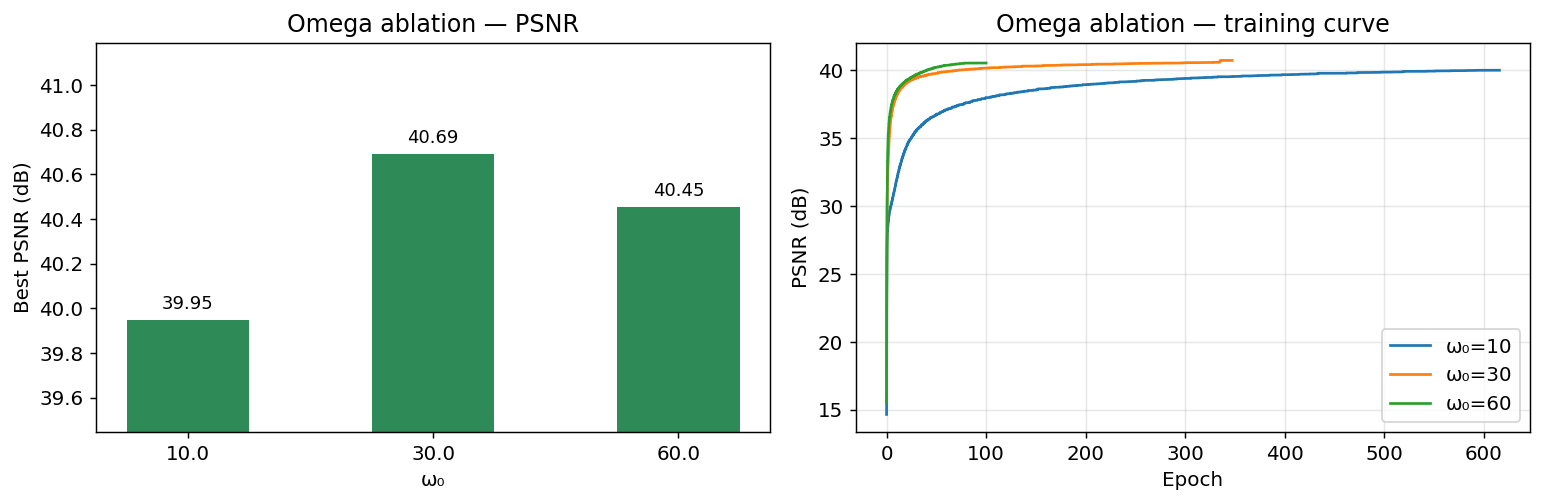

In [ ]:
omega = df[(df.layers == 3) & (df.neurons == 256)].sort_values('omega_0')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.bar(omega['omega_0'].astype(str), omega['best_psnr'], color='seagreen', width=0.5)
ax.set_xlabel('ω₀')
ax.set_ylabel('Best PSNR (dB)')
ax.set_title('Omega ablation — PSNR')
ax.set_ylim(omega['best_psnr'].min() - 0.5, omega['best_psnr'].max() + 0.5)
for bar, v in zip(ax.patches, omega['best_psnr']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, f'{v:.2f}', ha='center', fontsize=10)

ax = axes[1]
for _, row in omega.iterrows():
    name = row['run']
    if name in curves:
        c = curves[name]
        steps_per_ep = len(c) // row['epochs_trained']
        epochs = np.arange(len(c)) / max(steps_per_ep, 1)
        ax.plot(epochs, c, label=f"ω₀={int(row['omega_0'])}")
ax.set_xlabel('Epoch')
ax.set_ylabel('PSNR (dB)')
ax.set_title('Omega ablation — training curve')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(LOGS / 'ablation' / 'omega_ablation.pdf', dpi=600, bbox_inches='tight')
plt.show()

## 6 · Efficiency — PSNR vs parameters & training time

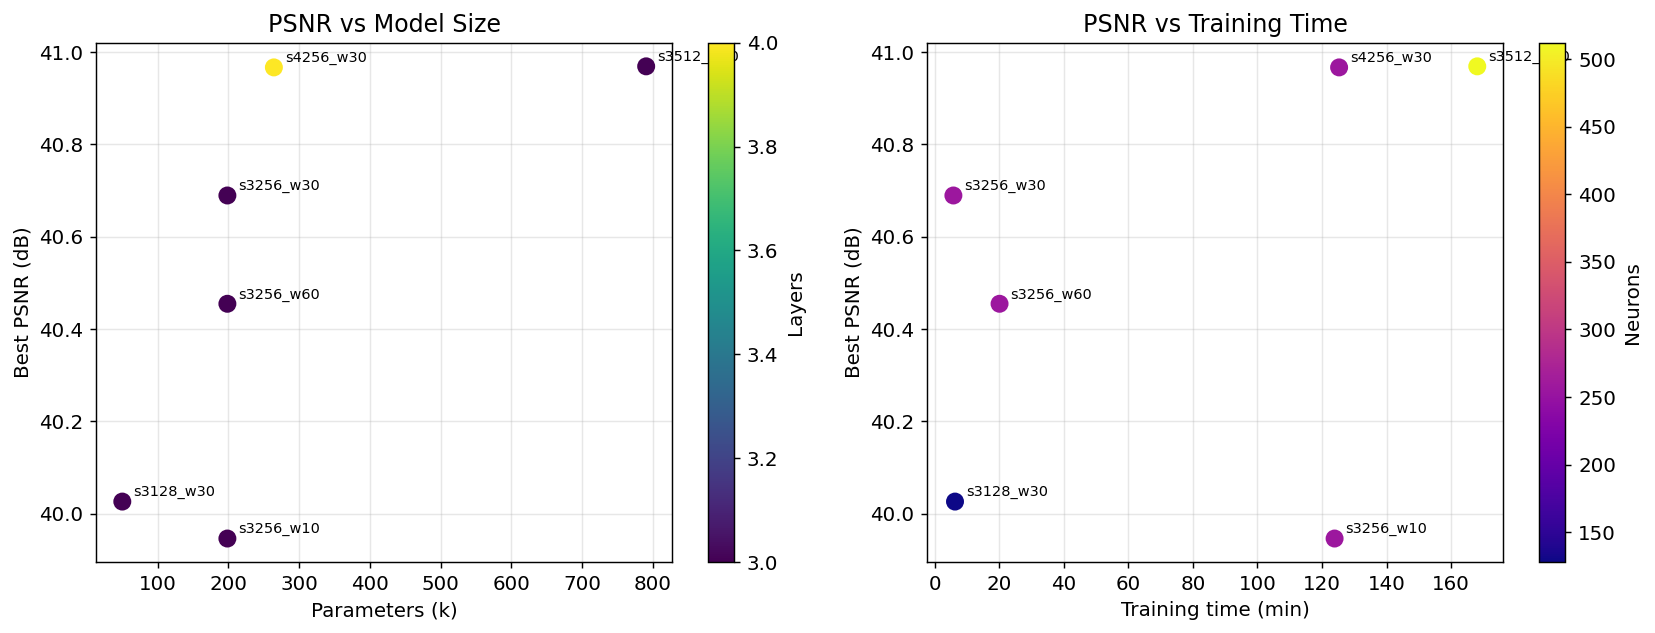

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
sc = ax.scatter(df['n_params_k'], df['best_psnr'], s=80, c=df['layers'], cmap='viridis', zorder=3)
plt.colorbar(sc, ax=ax, label='Layers')
for _, row in df.iterrows():
    ax.annotate(row['run'], (row['n_params_k'], row['best_psnr']),
                textcoords='offset points', xytext=(6, 3), fontsize=8)
ax.set_xlabel('Parameters (k)')
ax.set_ylabel('Best PSNR (dB)')
ax.set_title('PSNR vs Model Size')
ax.grid(alpha=0.3)

ax = axes[1]
sc = ax.scatter(df['train_min'], df['best_psnr'], s=80, c=df['neurons'], cmap='plasma', zorder=3)
plt.colorbar(sc, ax=ax, label='Neurons')
for _, row in df.iterrows():
    ax.annotate(row['run'], (row['train_min'], row['best_psnr']),
                textcoords='offset points', xytext=(6, 3), fontsize=8)
ax.set_xlabel('Training time (min)')
ax.set_ylabel('Best PSNR (dB)')
ax.set_title('PSNR vs Training Time')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(LOGS / 'ablation' / 'efficiency.pdf.pdf', dpi=600, bbox_inches='tight')
plt.show()

## 7 · All training curves

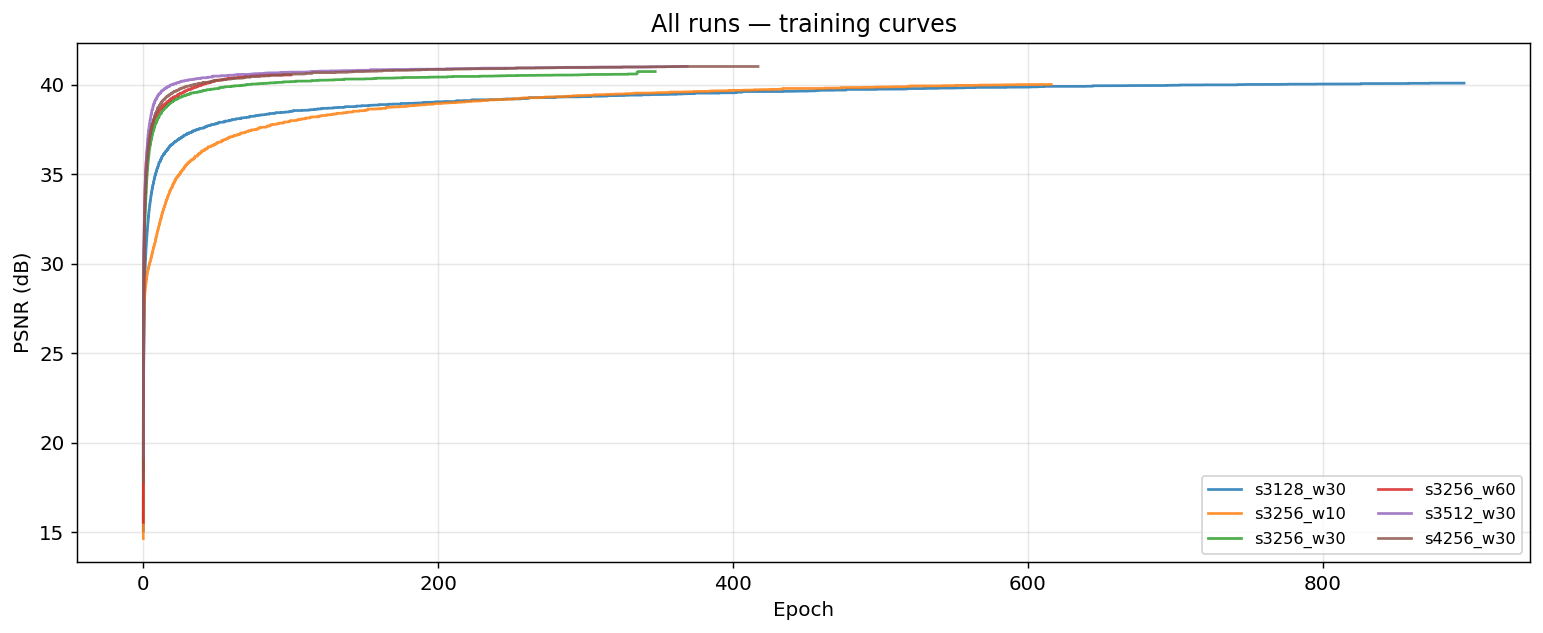

In [8]:
fig, ax = plt.subplots(figsize=(12, 5))
for name, c in sorted(curves.items()):
    row = df[df.run == name]
    if row.empty:
        continue
    ep = row['epochs_trained'].values[0]
    steps_per_ep = len(c) // ep
    epochs = np.arange(len(c)) / max(steps_per_ep, 1)
    ax.plot(epochs, c, label=name, alpha=0.85)

ax.set_xlabel('Epoch')
ax.set_ylabel('PSNR (dB)')
ax.set_title('All runs — training curves')
ax.legend(fontsize=9, ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(LOGS / 'ablation' / 'all_curves.pdf', dpi=600, bbox_inches='tight')
plt.show()

## 8 · Summary table + export CSV

In [9]:
has_metrics = df['ssim'].notna().any()
cols = ['run','layers','neurons','omega_0','n_params','best_psnr','best_loss','epochs_trained','batch_size']
renames = {'best_psnr':'PSNR (dB)', 'best_loss':'MSE', 'epochs_trained':'epochs'}
if has_metrics:
    cols  = cols[:6] + ['ssim','lpips'] + cols[6:]
    renames.update({'ssim':'SSIM ↑', 'lpips':'LPIPS ↓'})

summary = df[cols].copy()
summary['best_psnr'] = summary['best_psnr'].round(2)
summary['best_loss'] = summary['best_loss'].map('{:.2e}'.format)
if has_metrics:
    summary['ssim']  = summary['ssim'].map(lambda v: f'{v:.4f}' if v is not None else 'N/A')
    summary['lpips'] = summary['lpips'].map(lambda v: f'{v:.4f}' if v is not None else 'N/A')
summary = summary.rename(columns=renames)
summary.to_csv(LOGS / 'ablation' / 'results.csv', index=False)
print('Saved → logs/siren/ablation/results.csv')
display(summary)


Saved → logs/siren/ablation/results.csv


,run,layers,neurons,omega_0,n_params,PSNR (dB),SSIM ↑,LPIPS ↓,MSE,epochs,batch_size
0,s3128_w30,3,128,30.0,50177,40.03,0.9288,0.0608,9.94e-05,891,1048576
1,s3256_w10,3,256,10.0,198657,39.95,0.9286,0.0678,1.01e-04,616,1048576
2,s3256_w30,3,256,30.0,198657,40.69,0.9307,0.0477,8.53e-05,345,2097152
3,s3256_w60,3,256,60.0,198657,40.45,0.9303,0.0408,9.01e-05,100,1048576
4,s3512_w30,3,512,30.0,790529,40.97,0.9320,0.0425,8.00e-05,369,1048576
5,s4256_w30,4,256,30.0,264449,40.97,0.9318,0.0418,8.00e-05,417,1048576


## 10 · SSIM & LPIPS

In [10]:
import lpips as lpips_lib
import torch
import torch.nn.functional as F
from skimage.metrics import structural_similarity


# Requires section 9 (recon-setup) to have run first so that
# gt_vol, D, reconstruct(), and find_best_ckpt() are defined.

lpips_fn = lpips_lib.LPIPS(net='alex').cuda()
lpips_fn.eval()

N_LPIPS_SLICES = 20   # evenly-spaced z-slices
LPIPS_SZ       = 256  # downsample for LPIPS (speed + memory)

metrics_rows = []
for _, row in df.iterrows():
    run_dir      = LOGS / row['run']
    metrics_path = run_dir / 'metrics.json'

    if metrics_path.exists():
        m = json.loads(metrics_path.read_text())
        print(f"{row['run']}: cached   SSIM={m['ssim']:.4f}  LPIPS={m['lpips']:.4f}")
        metrics_rows.append({'run': row['run'], **m})
        continue

    find_best_ckpt_fn = globals().get('find_best_ckpt')
    if find_best_ckpt_fn is None:
        bests = sorted(run_dir.glob('checkpoints/*_best.pth'))
        ckpt = bests[-1] if bests else None
    else:
        ckpt = find_best_ckpt_fn(run_dir)
    if ckpt is None:
        print(f"{row['run']}: no checkpoint — skipping")
        continue

    model = SirenModel(
        in_features=3,
        hidden_features=int(row['neurons']),
        hidden_layers=int(row['layers']),
        out_features=1,
        omega_0=float(row['omega_0']),
    )
    sd = torch.load(ckpt, weights_only=True)
    sd = {k.replace('_orig_mod.', ''): v for k, v in sd.items()}
    model.load_state_dict(sd)
    recon = reconstruct(model)
    torch.cuda.empty_cache()

    # SSIM — average over all z-slices at full resolution
    ssim_val = float(np.mean([
        structural_similarity(gt_vol[z], recon[z], data_range=1.0)
        for z in range(D)
    ]))

    # LPIPS — 20 evenly-spaced slices, downsampled to 256 px
    z_idxs  = np.linspace(0, D - 1, N_LPIPS_SLICES, dtype=int)
    lp_vals = []
    for z in z_idxs:
        gt_t = torch.from_numpy(gt_vol[z])[None, None].expand(1, 3, -1, -1)
        rc_t = torch.from_numpy(recon[z])[None, None].expand(1, 3, -1, -1)
        gt_t = F.interpolate(gt_t, LPIPS_SZ, mode='bilinear', align_corners=False)
        rc_t = F.interpolate(rc_t, LPIPS_SZ, mode='bilinear', align_corners=False)
        with torch.no_grad():
            lp_vals.append(lpips_fn(gt_t.cuda() * 2 - 1, rc_t.cuda() * 2 - 1).item())
    lpips_val = float(np.mean(lp_vals))

    m = {'ssim': ssim_val, 'lpips': lpips_val}
    metrics_path.write_text(json.dumps(m, indent=2))
    print(f"{row['run']}: computed  SSIM={ssim_val:.4f}  LPIPS={lpips_val:.4f}  → saved")
    metrics_rows.append({'run': row['run'], **m})
    del recon

# Merge into df so section 8 summary picks them up on re-run
mdf = pd.DataFrame(metrics_rows)
for col in ('ssim', 'lpips'):
    df[col] = df['run'].map(mdf.set_index('run')[col])


Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/home/armin/miniconda3/envs/mink/lib/python3.8/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/armin/miniconda3/envs/mink/lib/python3.8/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /home/armin/miniconda3/envs/mink/lib/python3.8/site-packages/lpips/weights/v0.1/alex.pth
s3128_w30: cached   SSIM=0.9288  LPIPS=0.0608
s3256_w10: cached   SSIM=0.9286  LPIPS=0.0678
s3256_w30: cached   SSIM=0.9307  LPIPS=0.0477
s3256_w60: cached   SSIM=0.9303  LPIPS=0.0408
s3512_w30: cached   SSIM=0.9320  LPIPS=0.0425
s4256_w30: cached   SSIM=0.9318  LPIPS=0.0418


/home/armin/miniconda3/envs/mink/lib/python3.8/site-packages/lpips/lpips.py:107: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.load_state_dict(torch.load(model_path, ma

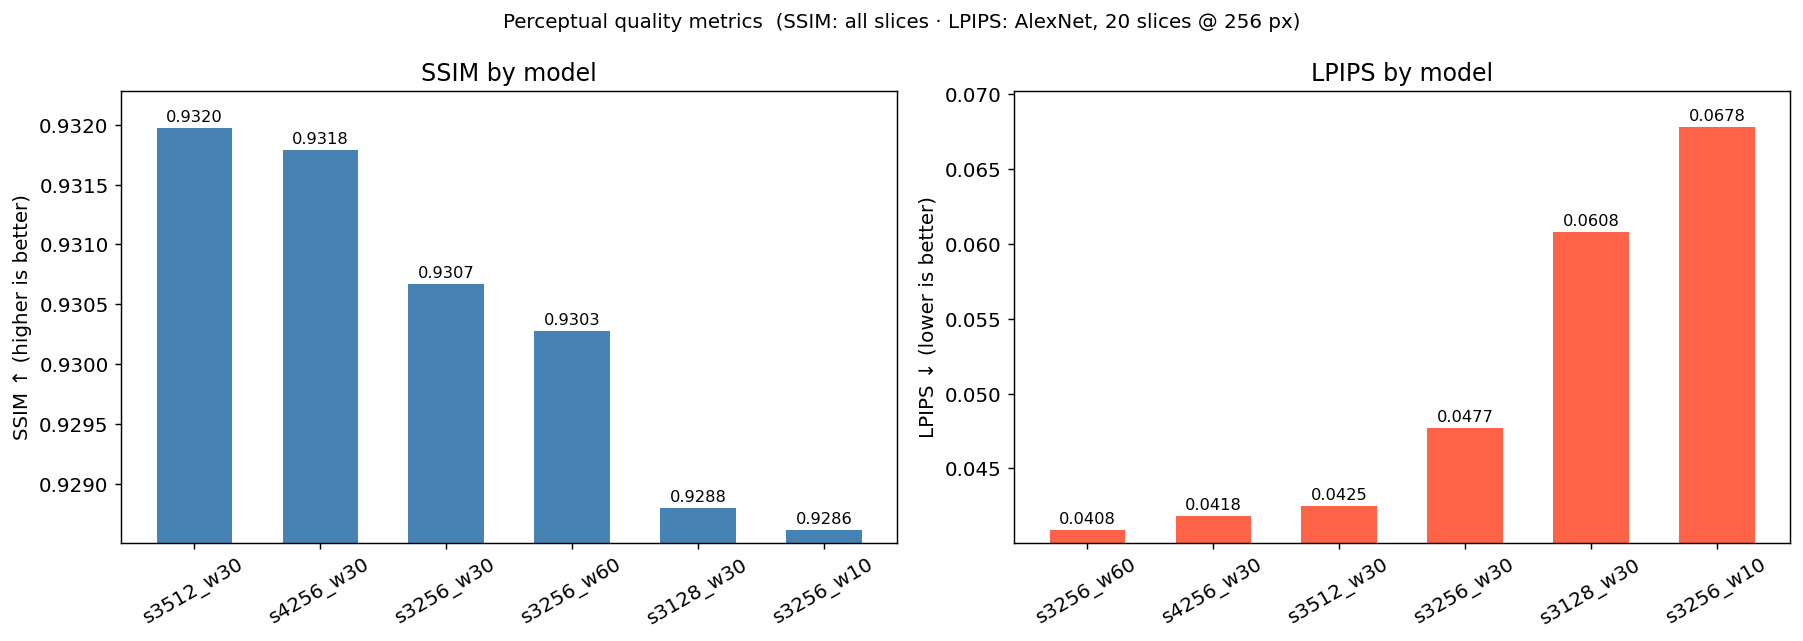

Saved → logs/siren/ablation/ssim_lpips.pdf


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, label, color, ascending in [
    (axes[0], 'ssim',  'SSIM ↑ (higher is better)',  'steelblue', False),
    (axes[1], 'lpips', 'LPIPS ↓ (lower is better)', 'tomato',    True),
]:
    vals = df[col].dropna()
    if vals.empty:
        ax.set_title(f'{col.upper()} — no data')
        continue
    ordered = df.sort_values(col, ascending=ascending).reset_index(drop=True)
    bars = ax.bar(ordered['run'], ordered[col], color=color, width=0.6)
    ax.set_ylabel(label)
    ax.set_title(f'{col.upper()} by model')
    ax.tick_params(axis='x', rotation=30)
    pad = (ordered[col].max() - ordered[col].min()) * 0.03 + 1e-6
    ax.set_ylim(ordered[col].min() - pad, ordered[col].max() + pad * 3)
    for bar, v in zip(bars, ordered[col]):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + pad * 0.3,
                f'{v:.4f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Perceptual quality metrics  (SSIM: all slices · LPIPS: AlexNet, 20 slices @ 256 px)',
             fontsize=11)
plt.tight_layout()
plt.savefig(LOGS / 'ablation' / 'ssim_lpips.pdf', dpi=600, bbox_inches='tight')
plt.show()
print('Saved → logs/siren/ablation/ssim_lpips.pdf')


## 9 · Volume reconstruction — GT / Recon / Diff  (slices 20 · 40 · 60 · 80)

In [12]:
import sys, torch, torch.nn.functional as F
sys.path.insert(0, str(Path('.')))
from src.siren import SirenModel
from skimage.metrics import structural_similarity
import lpips as lpips_lib
import tifffile

INPUT       = '10-2900-control-cell-05.oif-C0.v3dpbd.tif'
INFER_BATCH = 2**20
SLICE_IDXS  = [20, 40, 60, 80]
LPIPS_SZ    = 256

# ground truth
vol_raw = tifffile.imread(INPUT).astype('float32')
vmin_v, vmax_v = vol_raw.min(), vol_raw.max()
gt_vol  = (vol_raw - vmin_v) / (vmax_v - vmin_v)
D, H, W = gt_vol.shape
slice_idxs = [max(0, min(D-1, z)) for z in SLICE_IDXS]

# coordinate grid (built once, reused for every model)
axes_g   = [np.linspace(-1, 1, s, dtype='float32') for s in (D, H, W)]
coords_t = torch.from_numpy(
    np.stack([g.flatten() for g in np.meshgrid(*axes_g, indexing='ij')], axis=-1)
)

# perceptual loss (loaded once)
lpips_fn = lpips_lib.LPIPS(net='alex').cuda()
lpips_fn.eval()

def reconstruct(model):
    model.cuda().eval()
    parts = []
    with torch.no_grad():
        for i in range(0, len(coords_t), INFER_BATCH):
            parts.append(model(coords_t[i:i+INFER_BATCH].cuda()).squeeze(-1).cpu())
    return torch.cat(parts).numpy().reshape(D, H, W)

def find_best_ckpt(run_dir):
    bests = sorted(run_dir.glob('checkpoints/*_best.pth'))
    return bests[-1] if bests else None

def slice_metrics(gt_sl, rc_sl):
    """Per-slice SSIM and LPIPS (downsampled to LPIPS_SZ)."""
    ssim_val = structural_similarity(gt_sl, rc_sl, data_range=1.0)
    gt_t = torch.from_numpy(gt_sl)[None, None].expand(1, 3, -1, -1)
    rc_t = torch.from_numpy(rc_sl)[None, None].expand(1, 3, -1, -1)
    gt_t = F.interpolate(gt_t, LPIPS_SZ, mode='bilinear', align_corners=False)
    rc_t = F.interpolate(rc_t, LPIPS_SZ, mode='bilinear', align_corners=False)
    with torch.no_grad():
        lp_val = lpips_fn(gt_t.cuda()*2-1, rc_t.cuda()*2-1).item()
    return ssim_val, lp_val

print(f'Volume {D}\xd7{H}\xd7{W}   slices at z={slice_idxs}')


Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/home/armin/miniconda3/envs/mink/lib/python3.8/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/armin/miniconda3/envs/mink/lib/python3.8/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /home/armin/miniconda3/envs/mink/lib/python3.8/site-packages/lpips/weights/v0.1/alex.pth
Volume 113×1024×1024   slices at z=[20, 40, 60, 80]


/home/armin/miniconda3/envs/mink/lib/python3.8/site-packages/lpips/lpips.py:107: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.load_state_dict(torch.load(model_path, ma

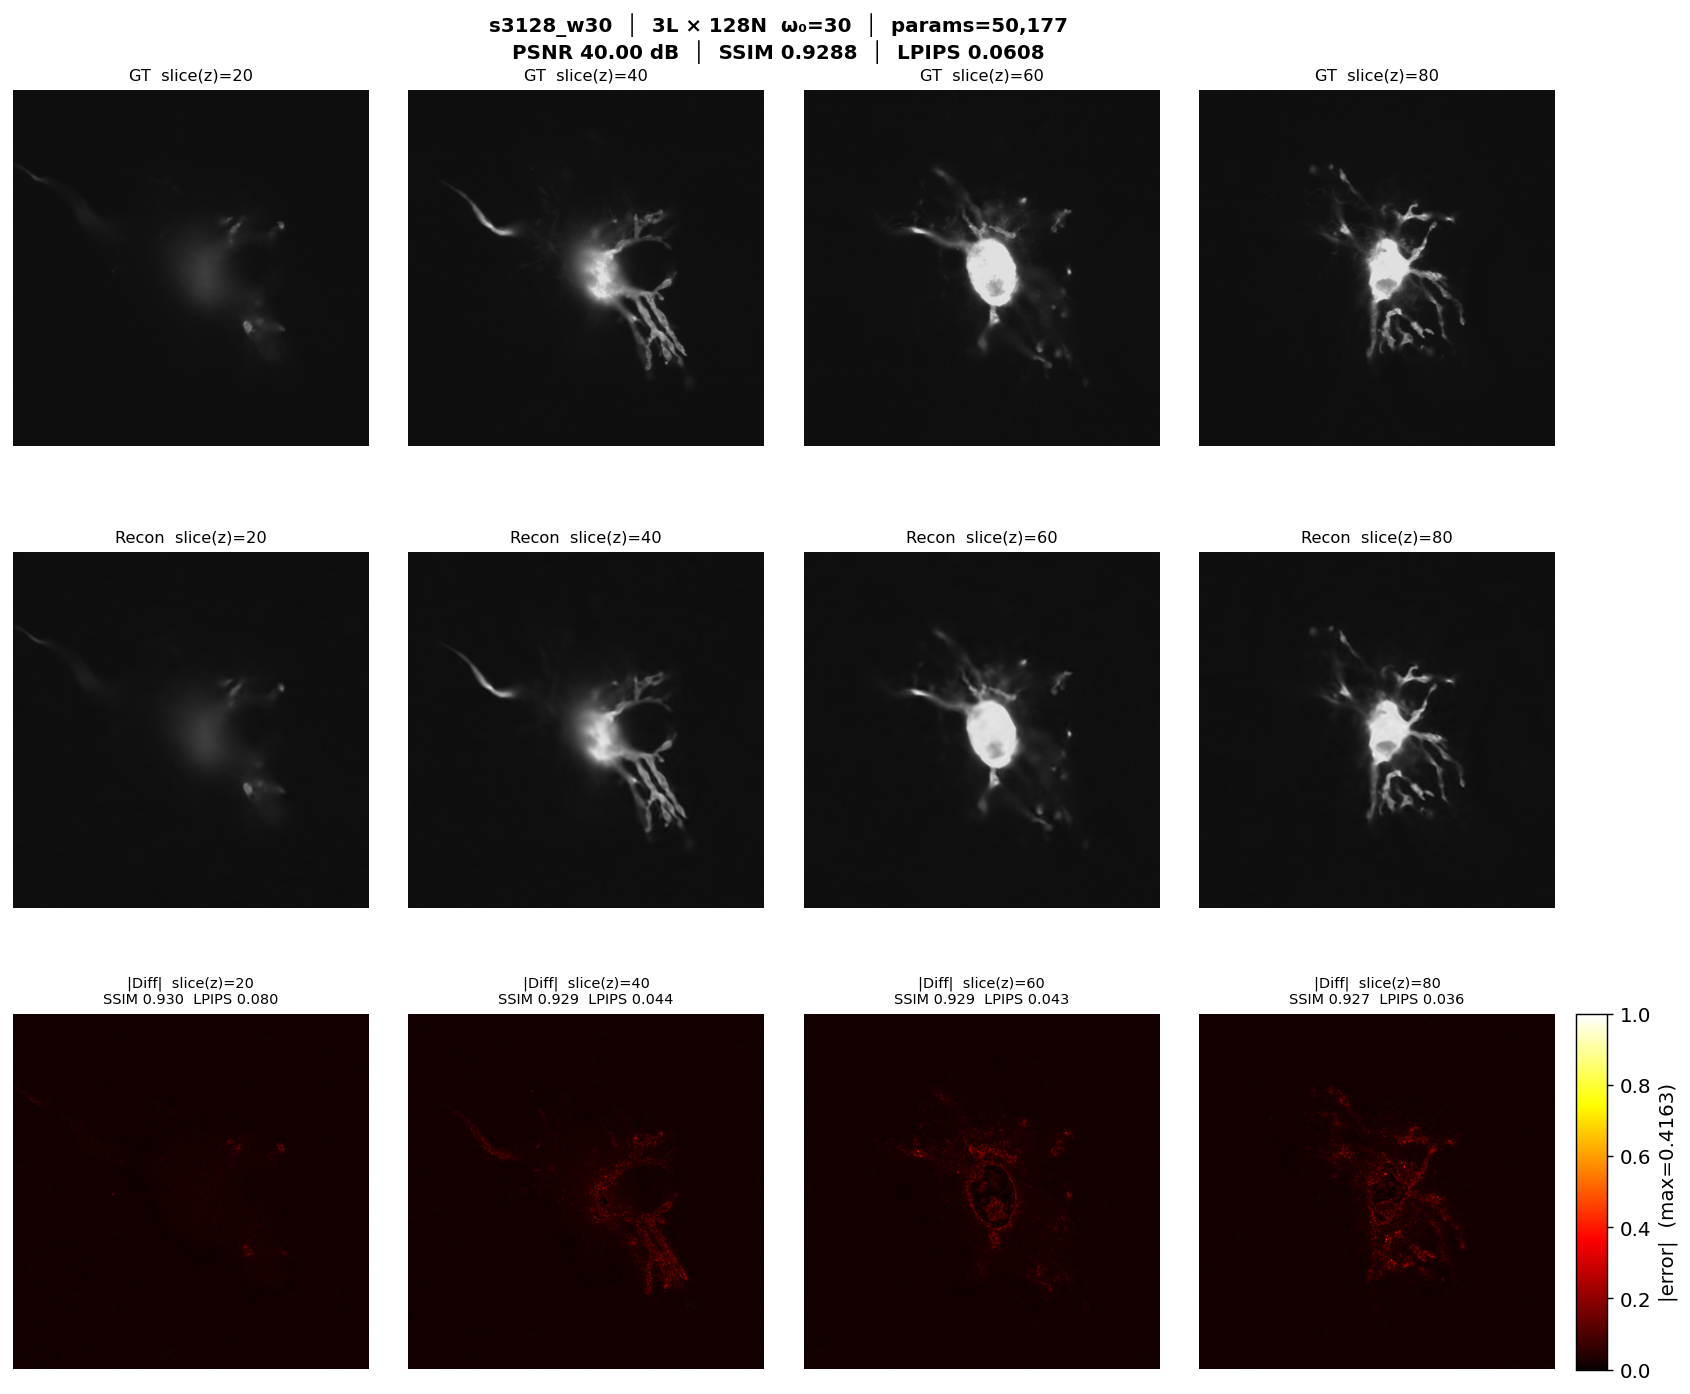

Saved → logs/siren/ablation/recon_s3128_w30.pdf


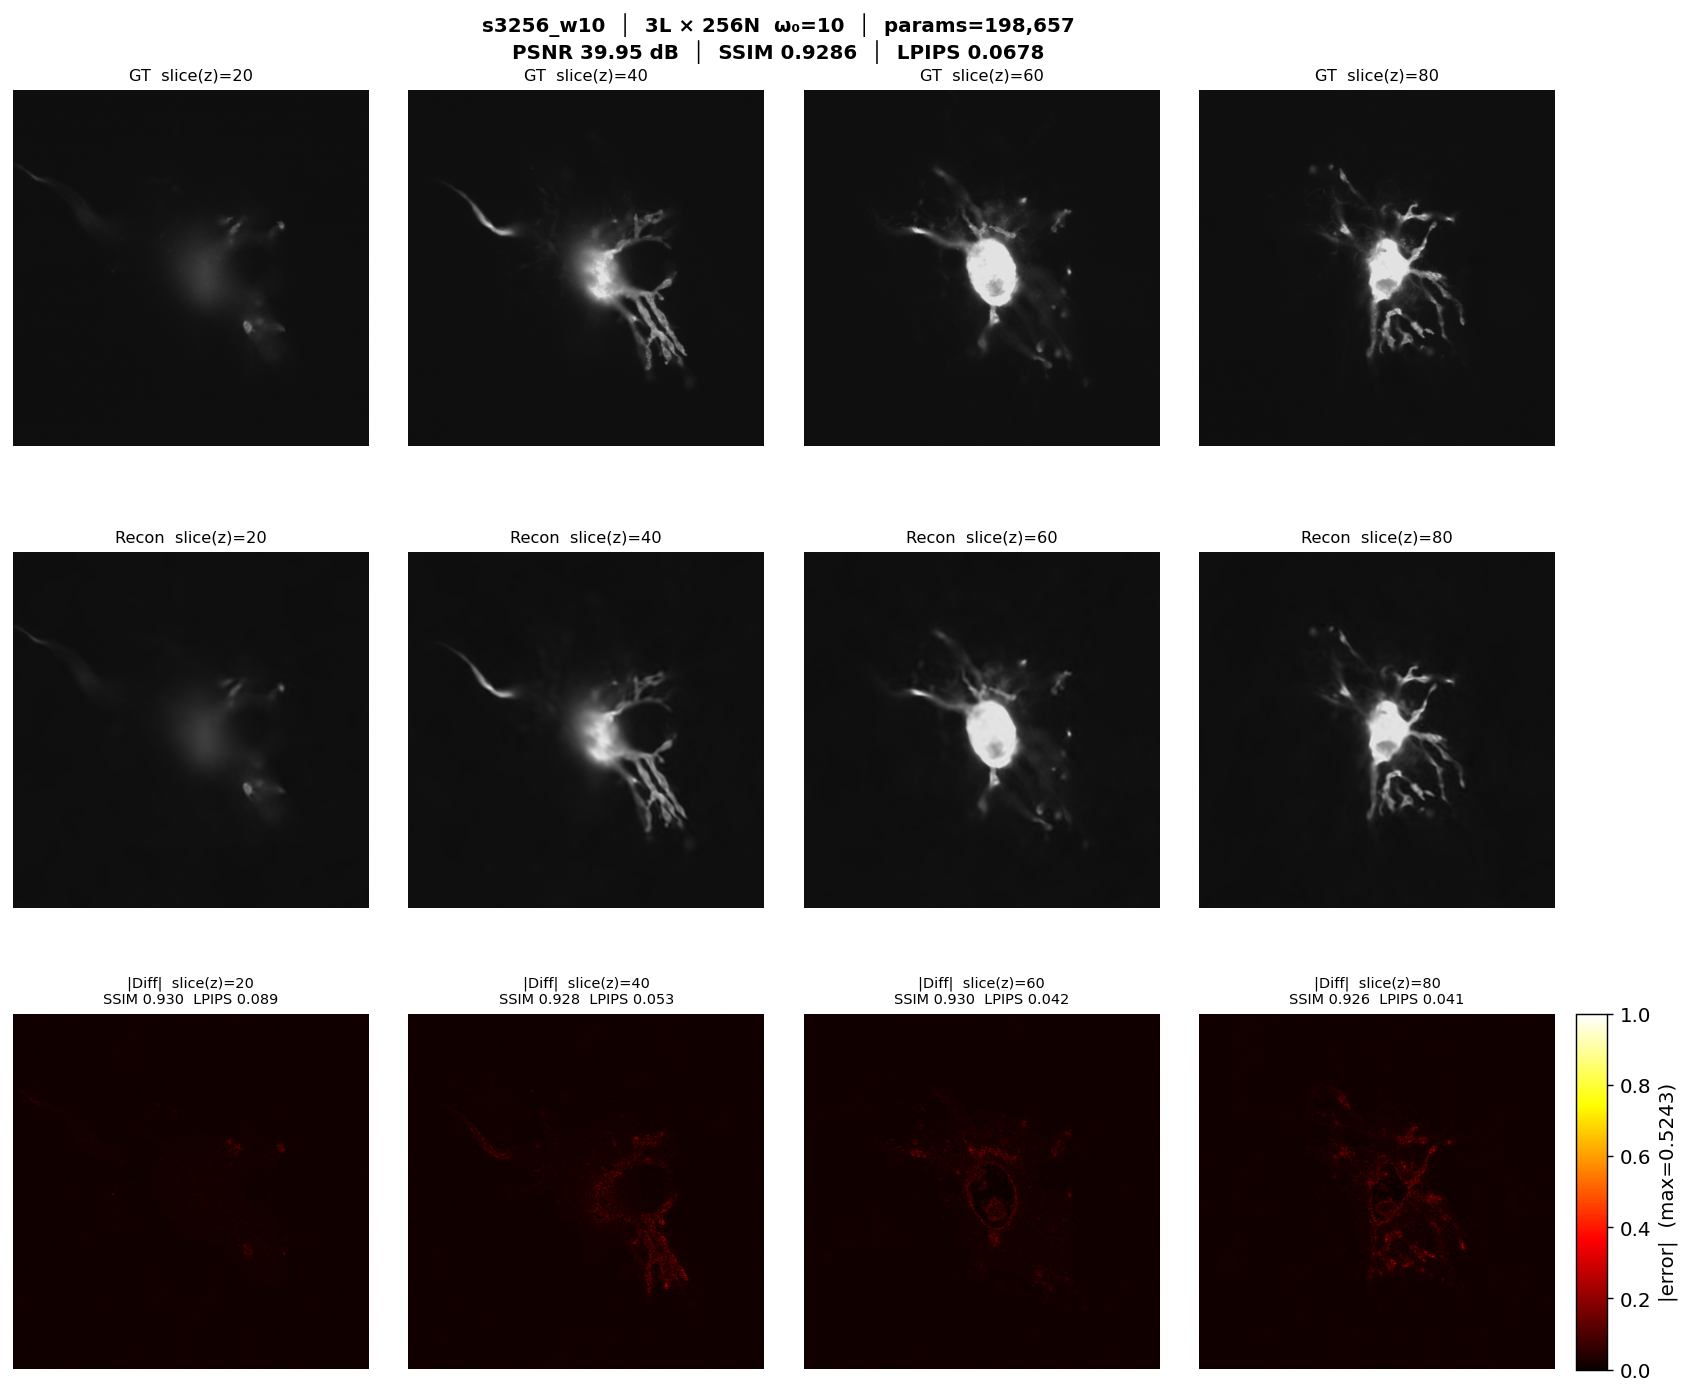

Saved → logs/siren/ablation/recon_s3256_w10.pdf


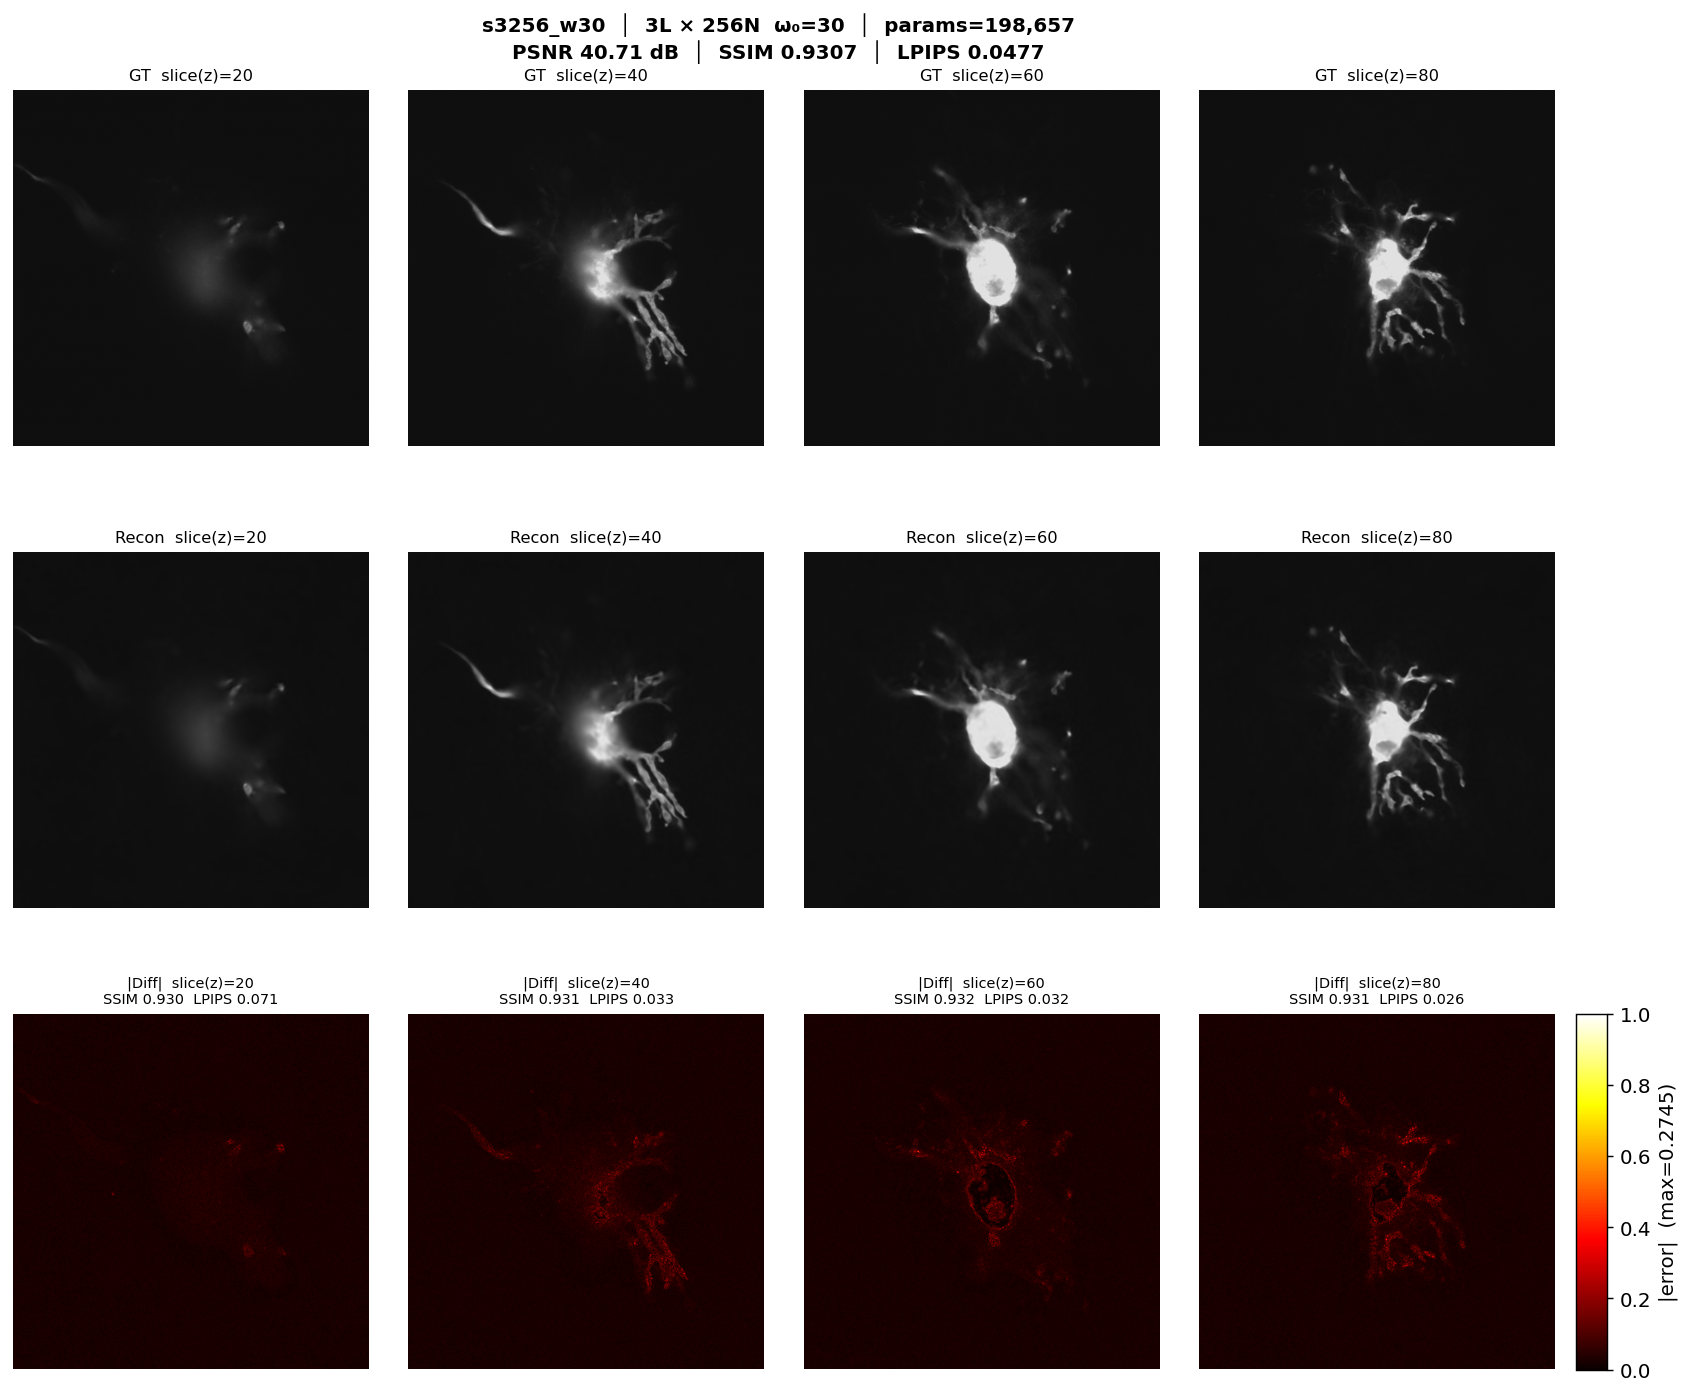

Saved → logs/siren/ablation/recon_s3256_w30.pdf


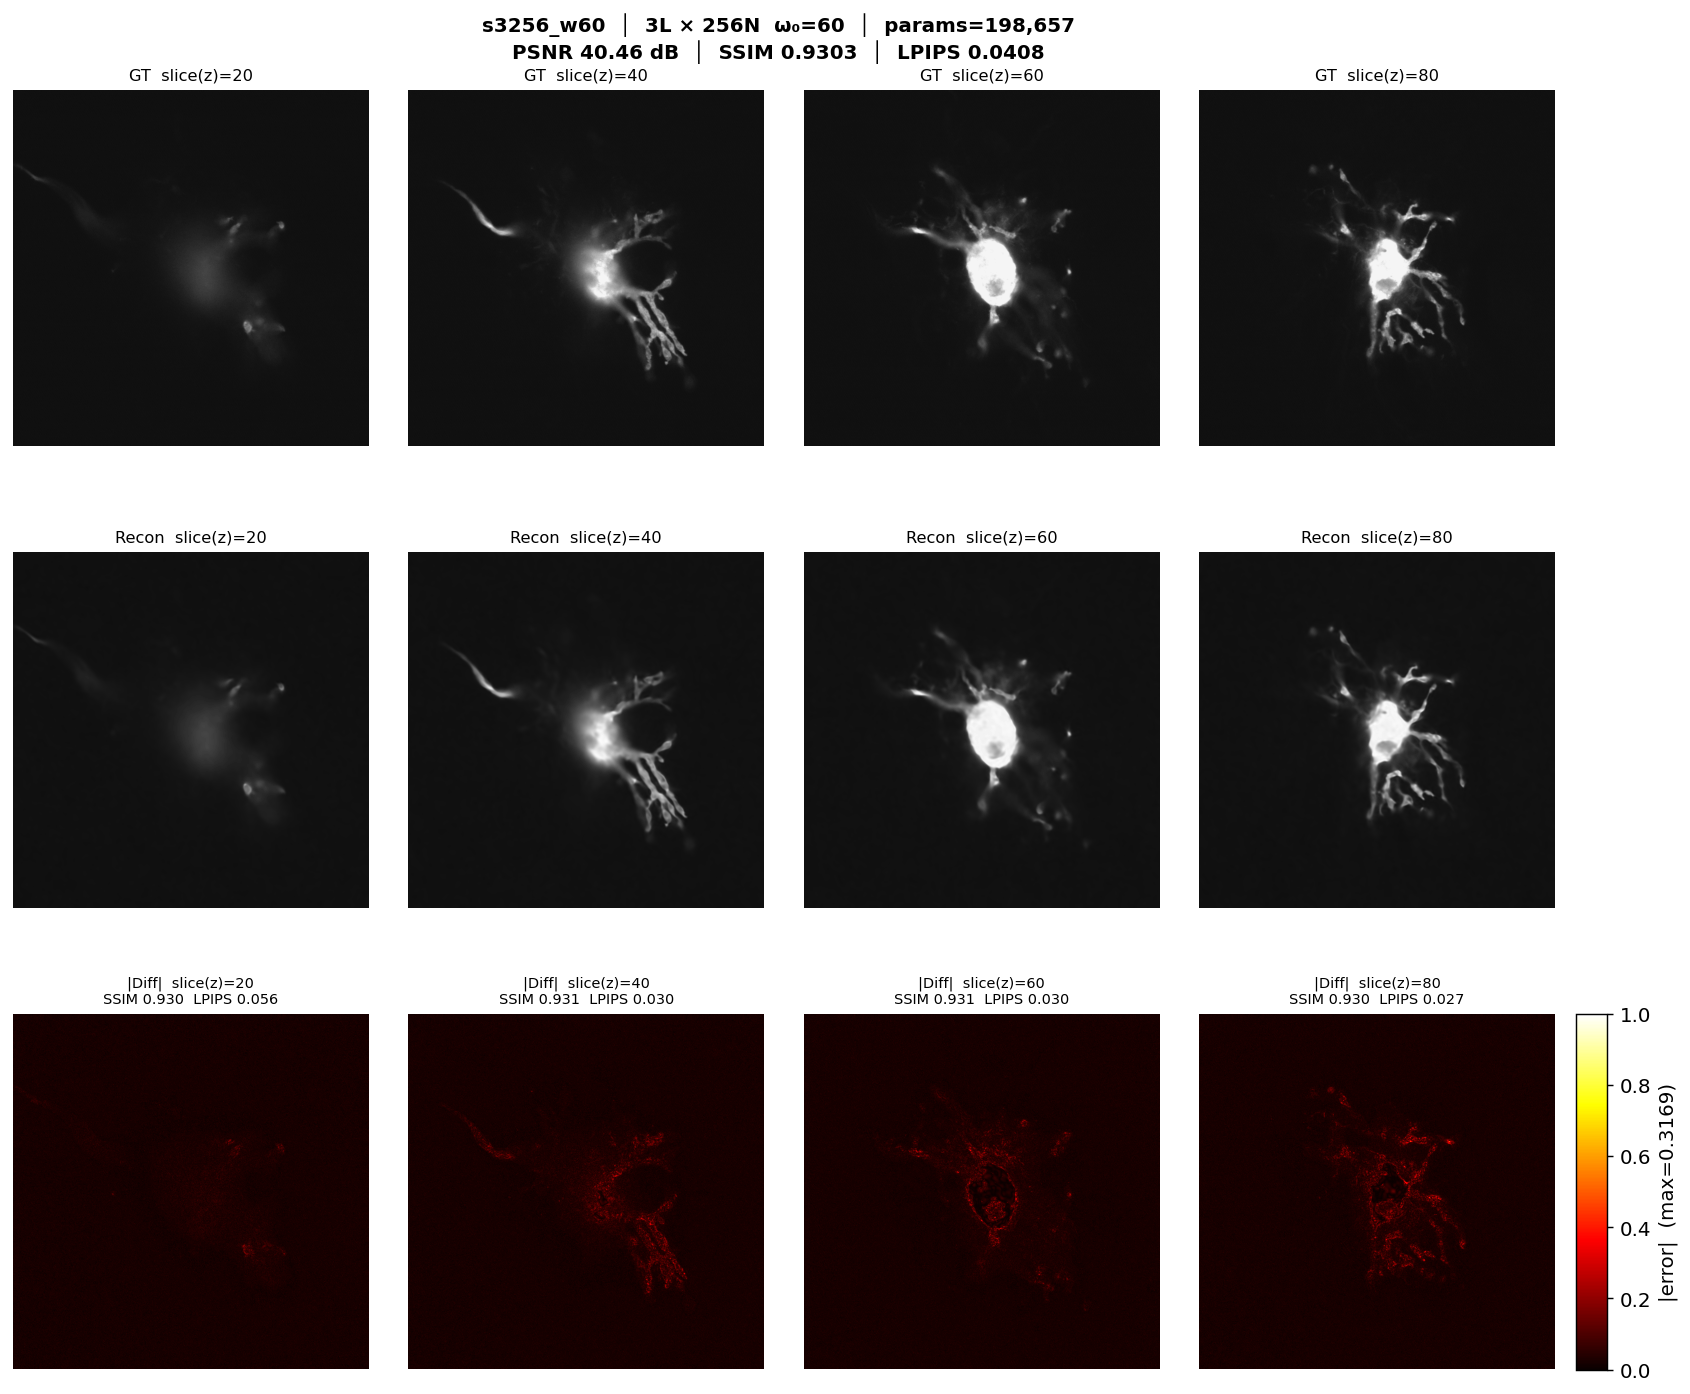

Saved → logs/siren/ablation/recon_s3256_w60.pdf


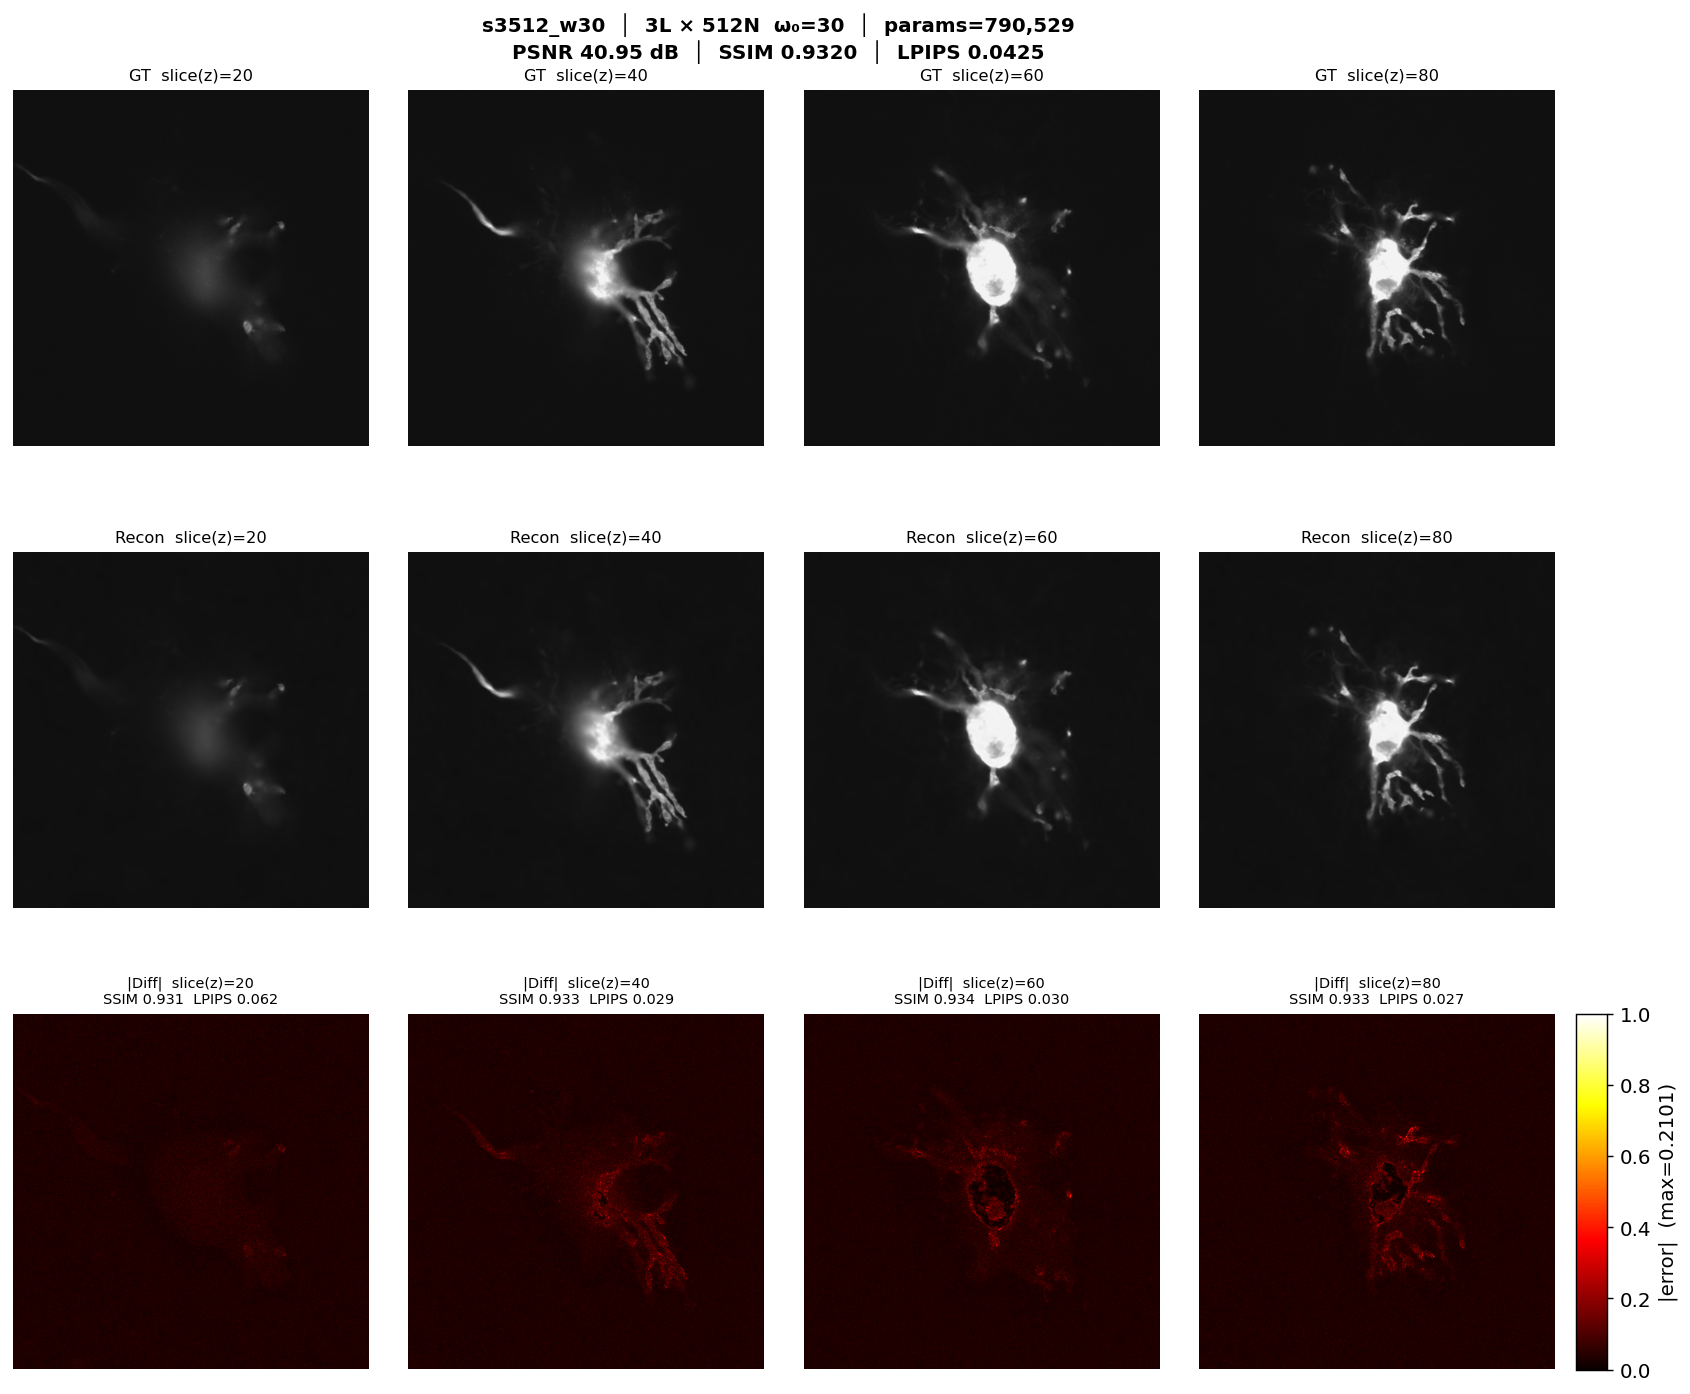

Saved → logs/siren/ablation/recon_s3512_w30.pdf


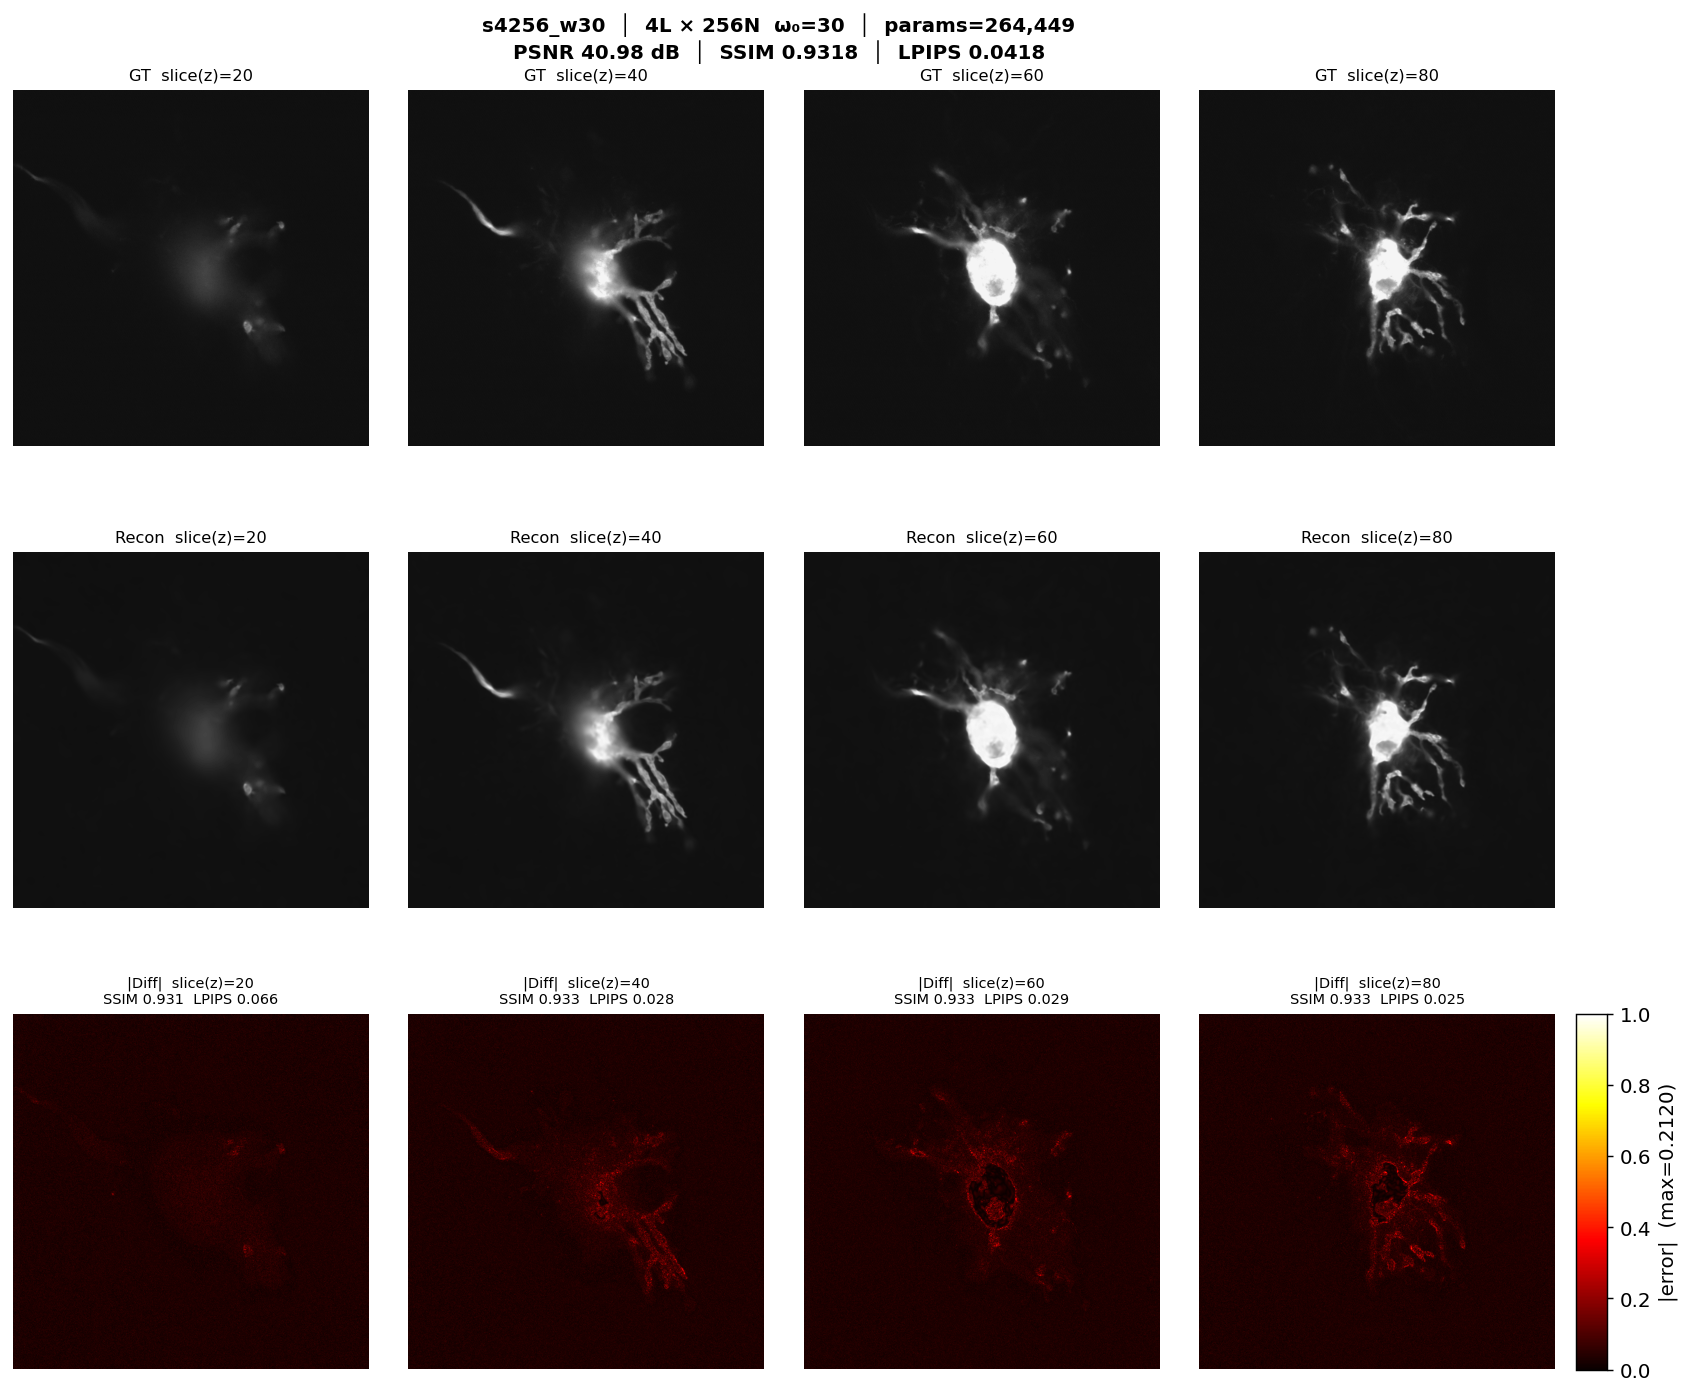

Saved → logs/siren/ablation/recon_s4256_w30.pdf


In [14]:
for _, row in df.iterrows():
    run_dir = LOGS / row['run']
    ckpt    = find_best_ckpt(run_dir)
    if ckpt is None:
        print(f"{row['run']}: no checkpoint, skipping")
        continue

    model = SirenModel(
        in_features=3,
        hidden_features=int(row['neurons']),
        hidden_layers=int(row['layers']),
        out_features=1,
        omega_0=float(row['omega_0']),
    )
    sd = torch.load(ckpt, weights_only=True)
    sd = {k.replace('_orig_mod.', ''): v for k, v in sd.items()}
    model.load_state_dict(sd)
    recon = reconstruct(model)
    diff  = np.abs(recon - gt_vol)
    psnr_full = float(-10 * np.log10(((recon - gt_vol)**2).mean() + 1e-8))

    fig, axes = plt.subplots(3, 4, figsize=(16, 12))
    fig.subplots_adjust(top=0.93, right=0.88, hspace=0.30, wspace=0.03)
    fig.suptitle(
        f"{row['run']}  \u2502  {int(row['layers'])}L \xd7 {int(row['neurons'])}N  "
        f"\u03c9\u2080={int(row['omega_0'])}  \u2502  params={int(row['n_params']):,}\n"
        f"PSNR {psnr_full:.2f} dB  \u2502  SSIM {float(row['ssim']):.4f}  \u2502  LPIPS {float(row['lpips']):.4f}",
        fontsize=11, fontweight='bold'
    )

    gr_min = min(gt_vol.min(), recon.min())
    gr_max = max(gt_vol.max(), recon.max())
    diff_max = diff.max() + 1e-8

    for col, z in enumerate(slice_idxs):
        axes[0, col].imshow(gt_vol[z], cmap='gray', vmin=gr_min, vmax=gr_max)
        axes[0, col].set_title(f'GT  slice(z)={z}', fontsize=9)

        axes[1, col].imshow(recon[z], cmap='gray', vmin=gr_min, vmax=gr_max)
        axes[1, col].set_title(f'Recon  slice(z)={z}', fontsize=9)

        im = axes[2, col].imshow(diff[z] / diff_max, cmap='hot', vmin=0, vmax=1)

        # per-slice quality metrics on the diff row
        s, lp = slice_metrics(gt_vol[z], recon[z])
        axes[2, col].set_title(f'|Diff|  slice(z)={z}\nSSIM {s:.3f}  LPIPS {lp:.3f}', fontsize=8)

    for ax in axes.flat:
        ax.axis('off')

    # align colorbar exactly to the diff row height and right edge
    fig.canvas.draw()
    p0 = axes[2, 0].get_position()
    p1 = axes[2, -1].get_position()
    cbar_ax = fig.add_axes([
        p1.x1 + 0.01,
        p0.y0,
        0.015,
        p0.y1 - p0.y0,
    ])
    fig.colorbar(im, cax=cbar_ax, label=f'|error|  (max={diff_max:.4f})')

    out = LOGS / 'ablation' / f"recon_{row['run']}.pdf"
    plt.savefig(out, dpi=600, bbox_inches='tight')
    plt.show()
    print(f'Saved \u2192 {out}')
    torch.cuda.empty_cache()


## 9b · Maximum Intensity Projection (MIP) — XY · XZ · ZY

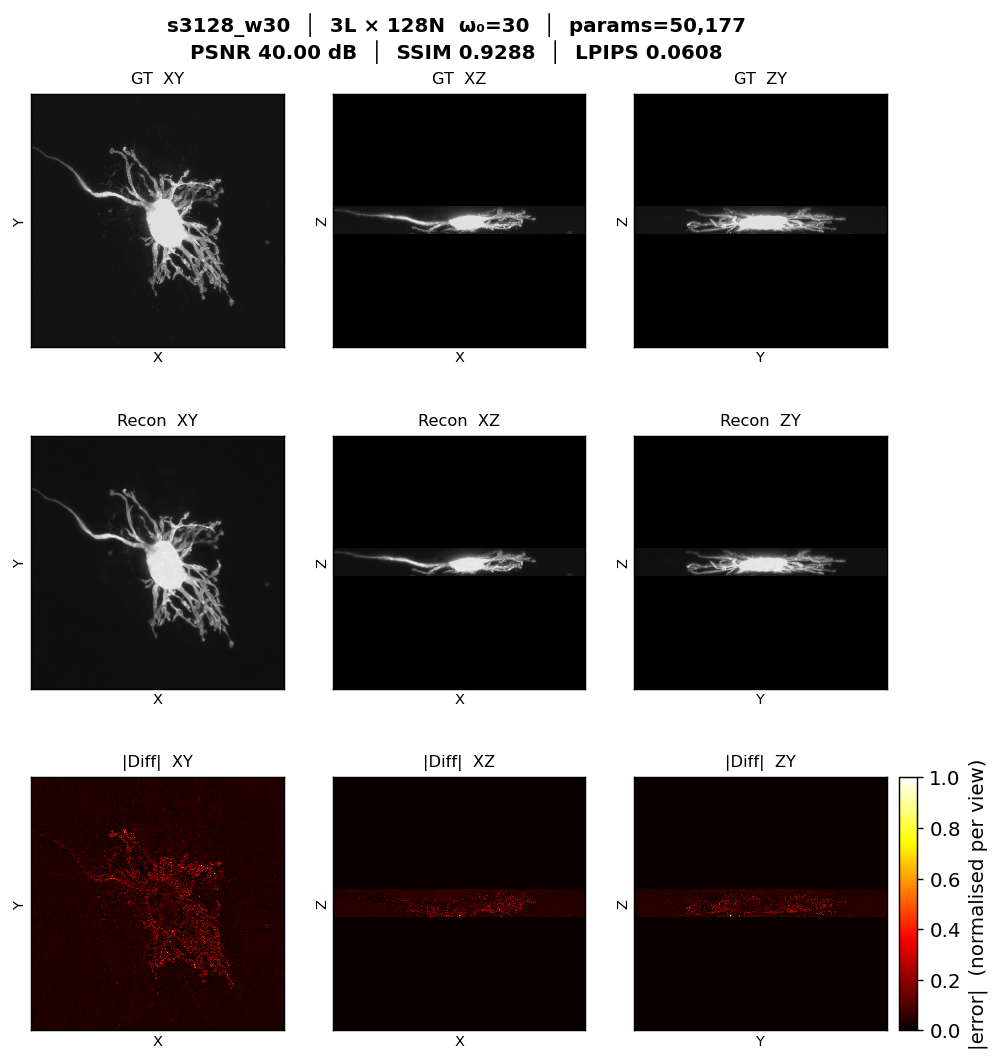

Saved → logs/siren/ablation/mip_s3128_w30.pdf


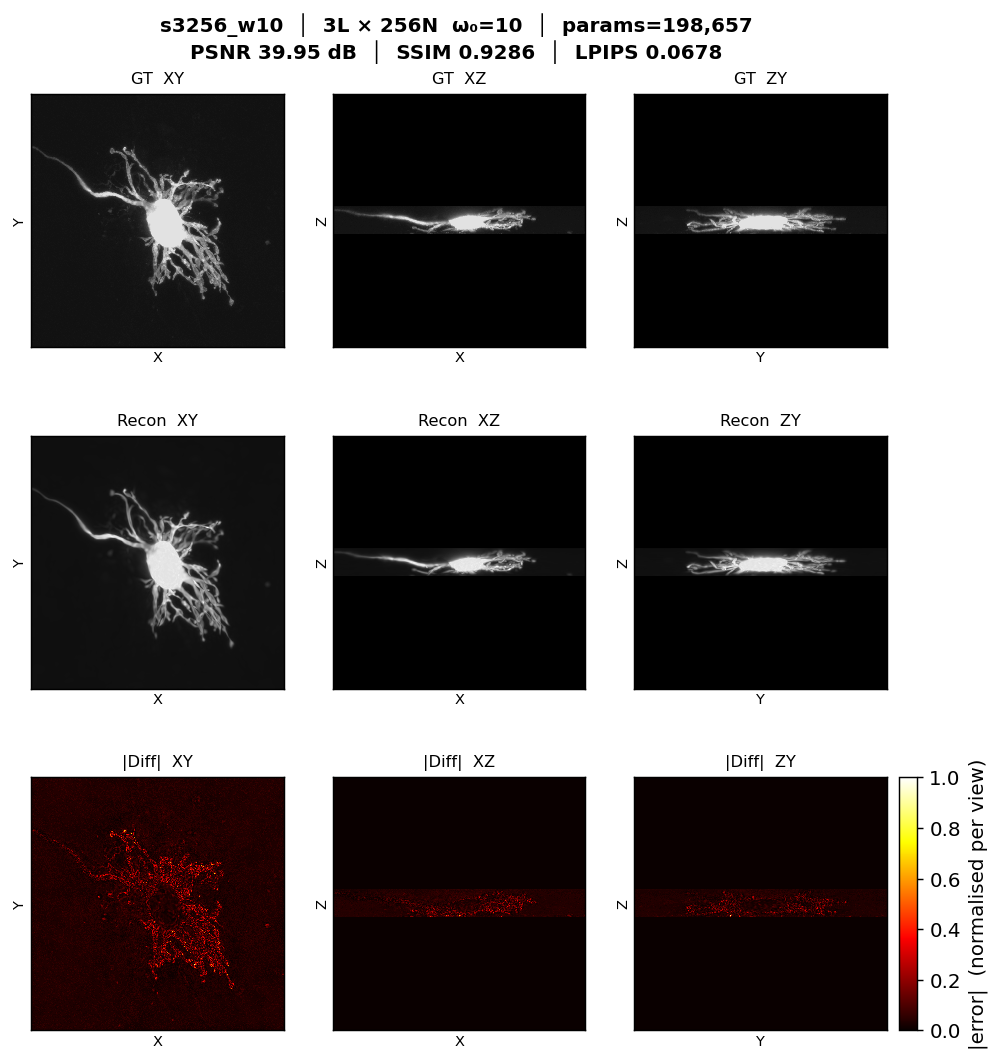

Saved → logs/siren/ablation/mip_s3256_w10.pdf


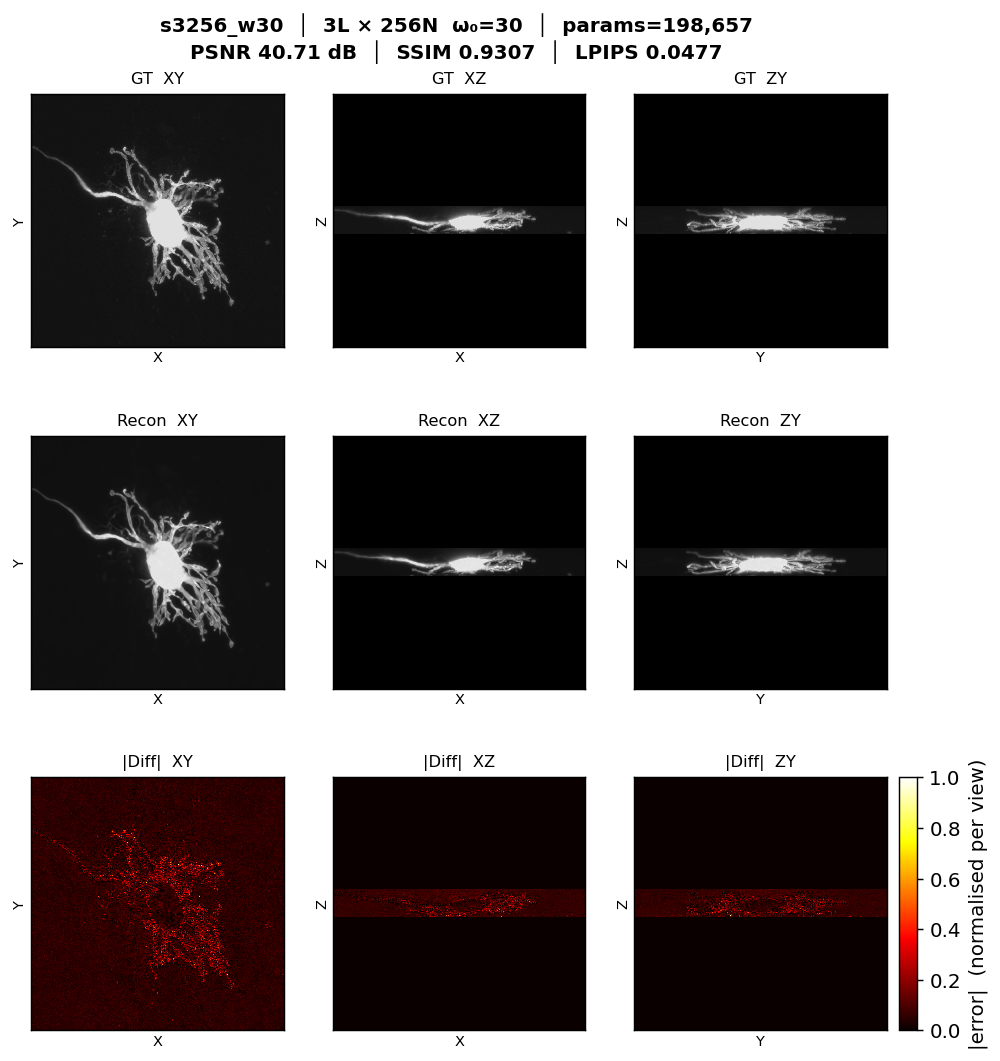

Saved → logs/siren/ablation/mip_s3256_w30.pdf


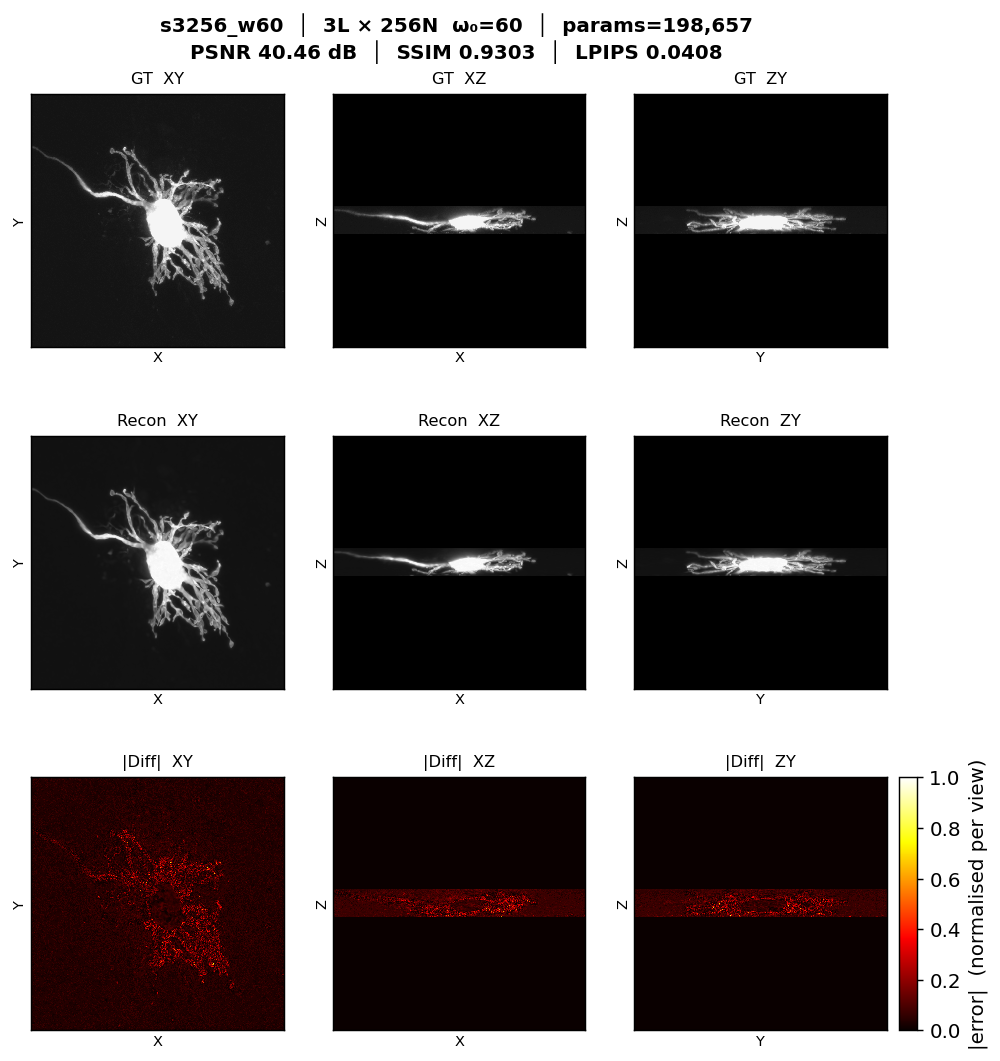

Saved → logs/siren/ablation/mip_s3256_w60.pdf


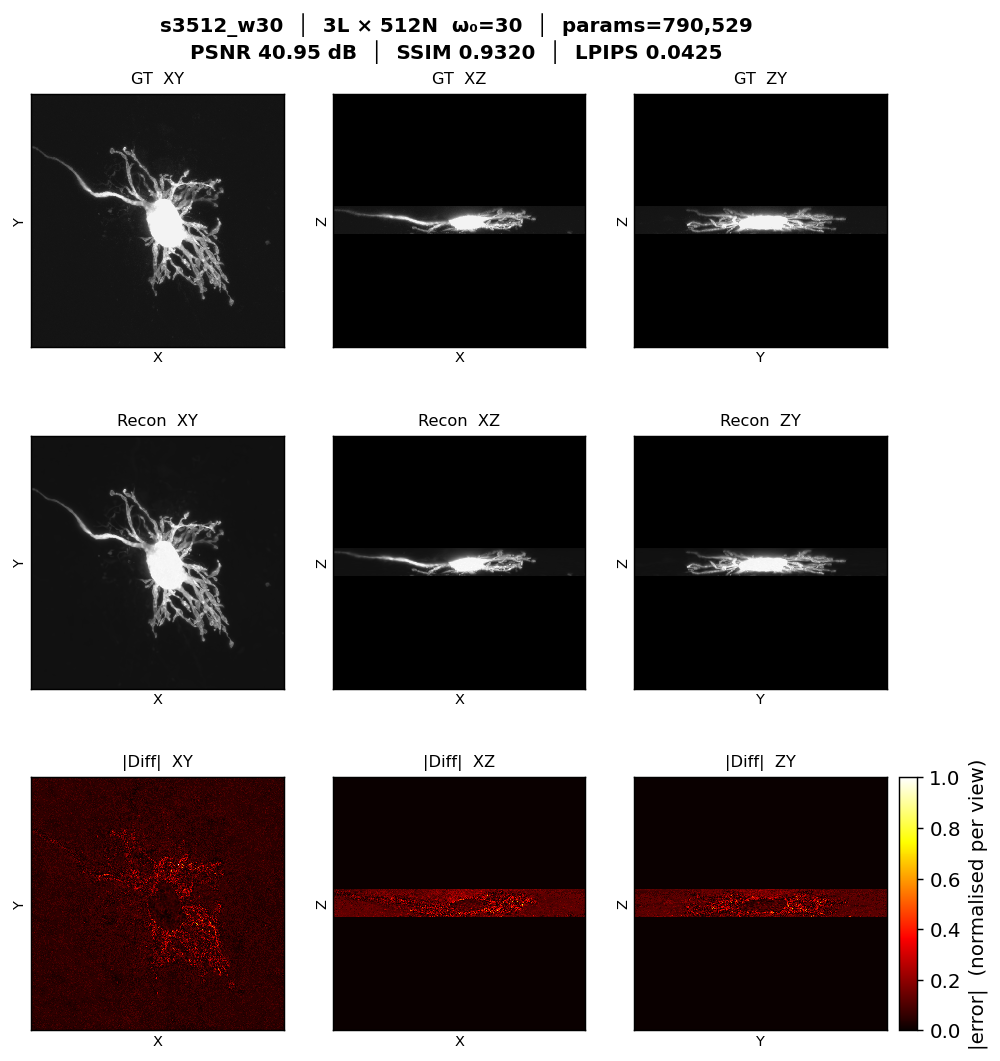

Saved → logs/siren/ablation/mip_s3512_w30.pdf


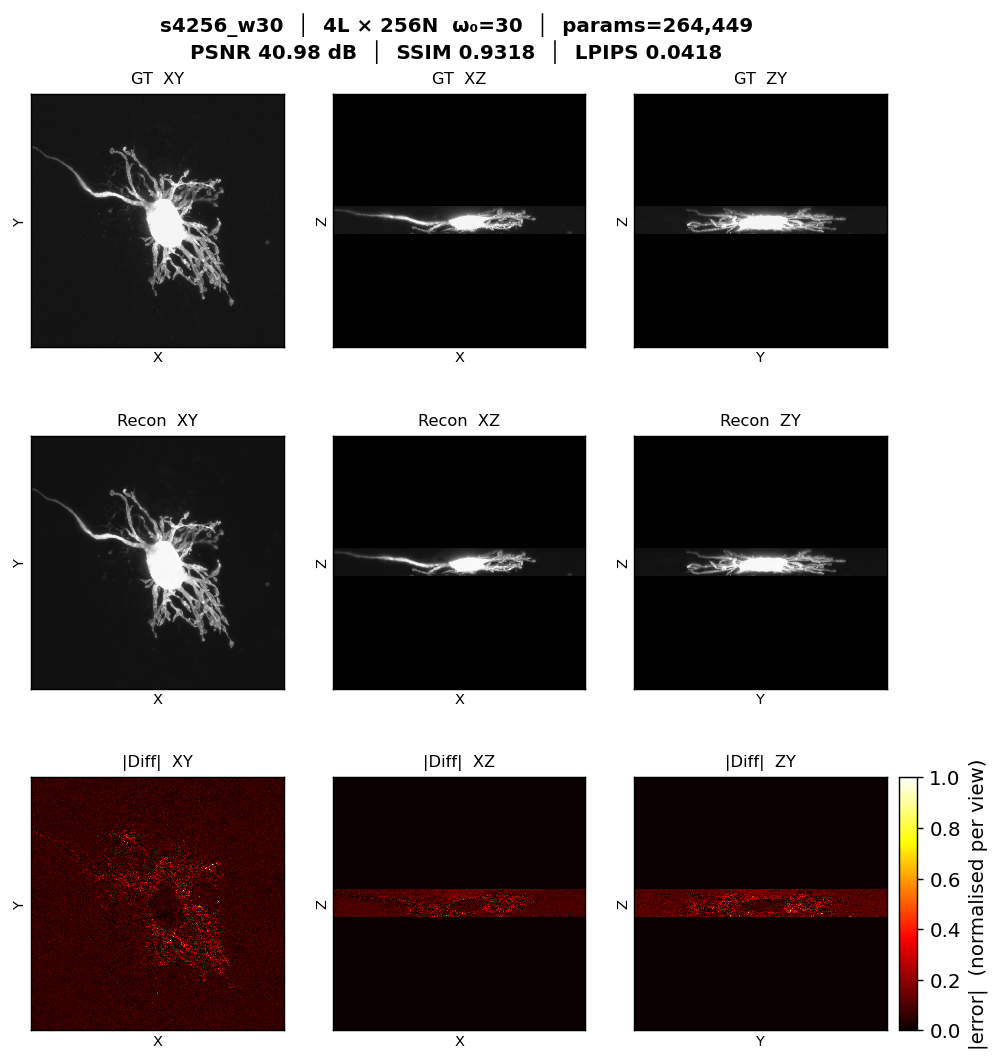

Saved → logs/siren/ablation/mip_s4256_w30.pdf


In [18]:
def pad_square(img, size=1024, fill=0.0):
    """Centre-pad img to size×size without stretching."""
    h, w   = img.shape
    out    = np.full((size, size), fill, dtype=np.float32)
    y0     = (size - h) // 2
    x0     = (size - w) // 2
    out[y0:y0 + h, x0:x0 + w] = img
    return out

for _, row in df.iterrows():
    run_dir = LOGS / row['run']
    ckpt    = find_best_ckpt(run_dir)
    if ckpt is None:
        print(f"{row['run']}: no checkpoint, skipping")
        continue

    model = SirenModel(
        in_features=3,
        hidden_features=int(row['neurons']),
        hidden_layers=int(row['layers']),
        out_features=1,
        omega_0=float(row['omega_0']),
    )
    sd = torch.load(ckpt, weights_only=True)
    sd = {k.replace('_orig_mod.', ''): v for k, v in sd.items()}
    model.load_state_dict(sd)
    recon = reconstruct(model)

    psnr_full = float(-10 * np.log10(((recon - gt_vol) ** 2).mean() + 1e-8))

    # MIP along each axis  (vol shape: D × H × W)
    #   XY → project along Z (axis 0) → (H, W)   already 1024×1024
    #   XZ → project along Y (axis 1) → (D, W)   113×1024 → padded to 1024×1024
    #   ZY → project along X (axis 2) → (D, H)   113×1024 → padded to 1024×1024
    views = [
        ('XY', 'X', 'Y', np.max(gt_vol, axis=0), np.max(recon, axis=0)),
        ('XZ', 'X', 'Z', np.max(gt_vol, axis=1), np.max(recon, axis=1)),
        ('ZY', 'Y', 'Z', np.max(gt_vol, axis=2), np.max(recon, axis=2)),
    ]

    fig, axes = plt.subplots(3, 3, figsize=(9, 9))
    fig.subplots_adjust(top=0.91, right=0.88, hspace=0.35, wspace=0.08)
    fig.suptitle(
        f"{row['run']}  \u2502  {int(row['layers'])}L \xd7 {int(row['neurons'])}N  "
        f"\u03c9\u2080={int(row['omega_0'])}  \u2502  params={int(row['n_params']):,}\n"
        f"PSNR {psnr_full:.2f} dB  \u2502  "
        f"SSIM {float(row['ssim']):.4f}  \u2502  LPIPS {float(row['lpips']):.4f}",
        fontsize=11, fontweight='bold'
    )

    vmin = min(gt_vol.min(), recon.min())
    vmax = max(gt_vol.max(), recon.max())

    for col, (label, xlabel, ylabel, gt_mip, rc_mip) in enumerate(views):
        diff_mip = np.abs(gt_mip - rc_mip)
        diff_max = diff_mip.max() + 1e-8

        # pad all projections to 1024×1024 — preserves true Z scale
        gt_sq   = pad_square(gt_mip)
        rc_sq   = pad_square(rc_mip)
        diff_sq = pad_square(diff_mip / diff_max)

        for row_idx, (img, cmap, vlo, vhi, title) in enumerate([
            (gt_sq,   'gray', vmin, vmax, f'GT  {label}'),
            (rc_sq,   'gray', vmin, vmax, f'Recon  {label}'),
            (diff_sq, 'hot',  0,    1,    f'|Diff|  {label}'),
        ]):
            ax = axes[row_idx, col]
            im_obj = ax.imshow(img, cmap=cmap, vmin=vlo, vmax=vhi,
                               aspect='equal', interpolation='nearest')
            ax.set_title(title, fontsize=9)
            ax.set_xlabel(xlabel, fontsize=8, labelpad=2)
            ax.set_ylabel(ylabel, fontsize=8, labelpad=2)
            ax.tick_params(left=False, bottom=False,
                           labelleft=False, labelbottom=False)
            if row_idx == 2:
                im = im_obj

    # colorbar aligned to diff row
    fig.canvas.draw()
    p0 = axes[2, 0].get_position()
    p1 = axes[2, -1].get_position()
    cbar_ax = fig.add_axes([p1.x1 + 0.01, p0.y0, 0.015, p0.y1 - p0.y0])
    fig.colorbar(im, cax=cbar_ax, label='|error|  (normalised per view)')

    out = LOGS / 'ablation' / f"mip_{row['run']}.pdf"
    plt.savefig(out, dpi=600, bbox_inches='tight')
    plt.show()
    print(f'Saved \u2192 {out}')
    torch.cuda.empty_cache()


In [4]:
import navis
from navis.interfaces import vfb

# Register FAFB / flybrain transforms
import flybrains

# If you have a neuron in another fly brain space
xf = navis.xform_brain(neuron, source="JRCFIB2018Fraw", target="FAFB14")

# Or mirror within FAFB
mirrored = navis.mirror_brain(xf, template="FAFB14")

# If you have a VFB ID, fetch the skeleton
sk = vfb.get_skeletons("VFB_...")

Welcome to the Virtual Fly Brain API
See the documentation at: https://virtualflybrain.org/docs/tutorials/apis/

Establishing connections to https://VirtualFlyBrain.org services...


KeyboardInterrupt: 

In [10]:
# VFB connect object wraps connections and queries to public VFB servers.

from vfb_connect import vfb

# Get TermInfo for Types/Classes, DataSets and anatomical individuals.

# vfb.term('FBbt_00003686')

# vfb.terms(['Ito02013'])

# vfb.terms(['VFB_00010001'])
vfb.get_datasets()

# Get all terms relevant to a brain region (all parts and all overlapping cells. You can query by label, symbol, synonym, id or xref.

vfb.get_terms_by_region('all parts')

No direct match found for all parts
Error: Unrecognized value: all parts


ValueError: Query includes unknown term label: 'overlaps' some 'all parts'